In [1]:
import os
import joblib
import pickle
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams, cycler
from matplotlib.cm import ScalarMappable
import seaborn as sns
import tensorflow as tf
from scipy.stats import pearsonr, gaussian_kde, ecdf, kruskal, friedmanchisquare
from sklearn.decomposition import PCA
import sys
sys.path.append(os.path.join('c:\\', *os.getcwd().split('\\')[1:-1]))
from sgcc9 import *

In [2]:
plt.rcParams['figure.dpi'] = 300
fontsize = 8
linewidth = 0.5

In [3]:
X = tf.convert_to_tensor([0.02,0.04,0.08,0.1,0.12,0.16,0.2,0.24,0.28,0.32], dtype = tf.float32)

In [4]:
v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'v1_ori_phase_condition_pcascores_wcomp.pkl')
v1_scores = pd.read_pickle(v1_xs_file)
v1_scores_condition_averaged = np.array([np.array(x) for x in v1_scores.scores.values]).mean(0)
Y_true = v1_scores_condition_averaged[:2,:,:].transpose(0,2,1)

In [5]:
param_bounds = {
    "fts": [0, 175],
    "t": [40, 125],
    "ampc": [0.01, 0.1],
    'ampm': [0,3],
    "ampg": [0.1, 4],
    "ampw": [0.01,0.08],
    "d": [10, 40],
    "inh_d": [0, 40],
    "inh_w": [0, 3],
}

## Optimization results

In [6]:
P = joblib.load(
    os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'best_permutation.pkl')
)

In [7]:
sgcc = SGCCircuit(param_bounds, enforce_permutation=P)

In [8]:
modfile = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'sgcc_mop_4_18_26.pkl')
with open(modfile, 'rb') as f:
    optimized_model = pickle.load(f)

In [9]:
sgcc.load_saved_parameters(optimized_model['final_epoch_params'])

In [10]:
loss_decay = optimized_model['loss_decay']

In [11]:
res = optimized_model
param_history = res['param_history']

In [12]:
loss_decay = res['loss_decay']
last_epoch = loss_decay[-1]
best = np.where(last_epoch == last_epoch.min())[0][0]
print(f"Index of best parameters: {best}, loss = {last_epoch[best]}")

Index of best parameters: 710, loss = 0.06439208984375


In [13]:
def minmax_norm(array, lower, upper):
    if (array.max() - array.min()) != 0:
        norm = (array - array.min()) / (array.max() - array.min())
        return lower + (norm * (upper-lower))
    else:
        return array

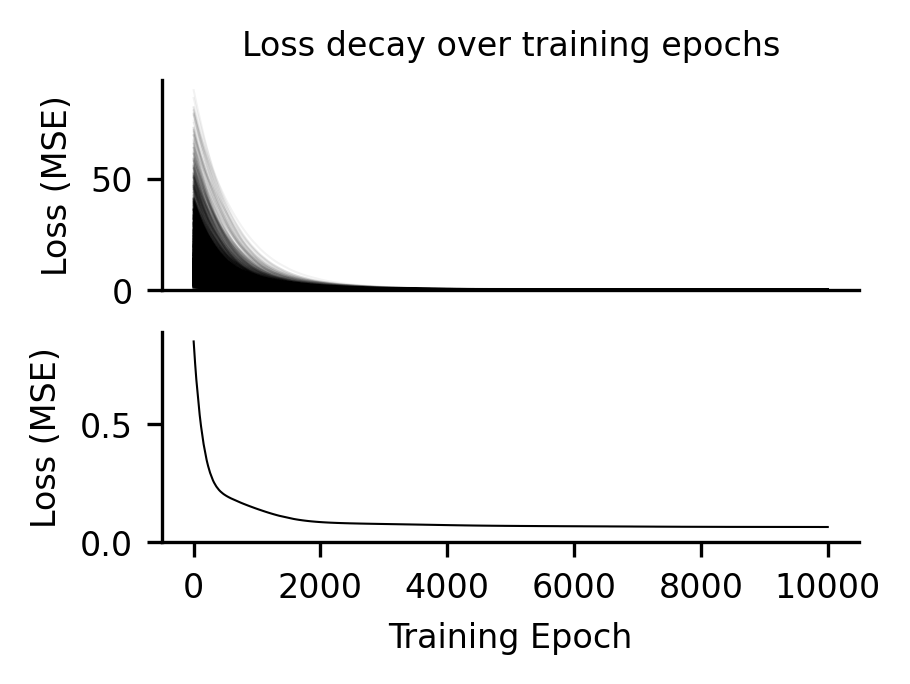

In [14]:
fig, ax = plt.subplots(2, figsize = (3,2))

for i, decay in enumerate(loss_decay.T):
    ax[0].plot(decay, alpha = 0.05, color = 'black', linewidth = linewidth)

ax[1].set_xlabel("Training Epoch", fontsize = fontsize)
ax[0].set_ylabel("Loss (MSE)", fontsize = fontsize)
ax[0].set_ylim(0,)
ax[0].set_xticks([])

ax[1].set_ylabel("Loss (MSE)", fontsize = fontsize)
ax[1].plot(loss_decay[:,best], alpha = 1, color = 'black', linewidth = linewidth)
ax[1].set_ylim(0.)
ax[0].set_title("Loss decay over training epochs", fontsize = fontsize)

for i in range(2):
    ax[i].tick_params(labelsize = fontsize)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)

# figname = '2d_model_loss_decay_first_round_4_18.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

In [15]:
loss_decay.shape

(10000, 4000)

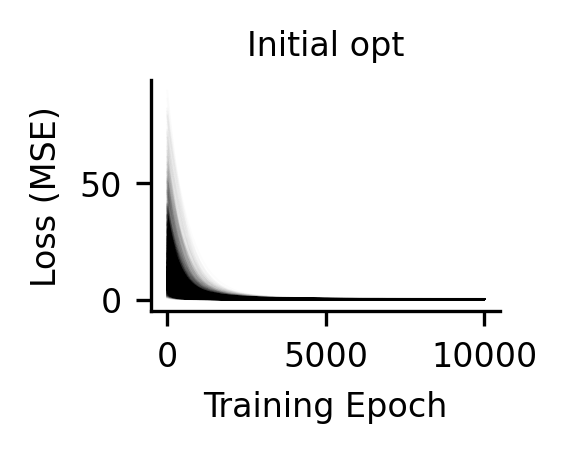

In [16]:
fig, ax = plt.subplots(1, figsize = (1.5,1))

ax.plot(loss_decay, alpha = 0.01, color = 'black', linewidth = linewidth)
ax.set_xlabel("Training Epoch", fontsize = fontsize)
ax.set_ylabel("Loss (MSE)", fontsize = fontsize)
ax.set_ylim(-5,)
#ax.set_xticks([])
ax.set_title("Initial opt", fontsize = fontsize)


ax.tick_params(labelsize = fontsize)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# figname = '2d_model_loss_decay_first_round_4_18.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

In [17]:
lsi = np.argsort(loss_decay[-1])

Text(0.5, 1.0, 'Loss distribution on final training epoch')

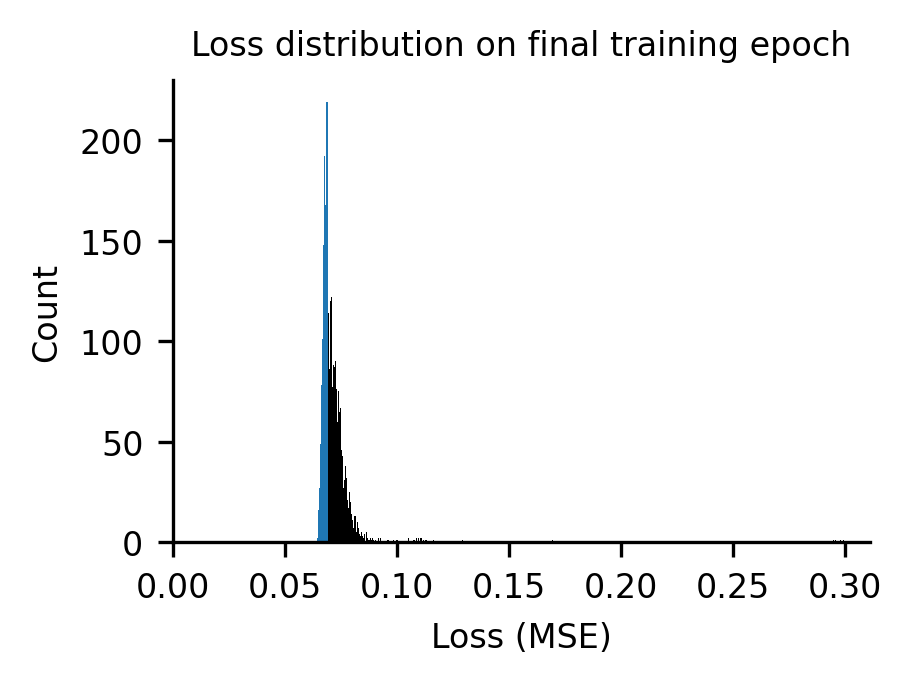

In [18]:
fig, ax = plt.subplots(figsize = (3,2))
ax.hist(loss_decay[-1], bins = 1000, color = 'black')
ax.hist(loss_decay[-1][lsi[:1000]])
ax.tick_params(labelsize = fontsize)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel("Count", fontsize = fontsize)
ax.set_xlabel("Loss (MSE)", fontsize = fontsize)
ax.set_xticks(np.arange(0,0.35,0.05))
#ax.set_ylim(0,60)
ax.set_title("Loss distribution on final training epoch", fontsize = fontsize)

Text(0.525, 1.05, 'Distribution of V1 parameters post-optimization')

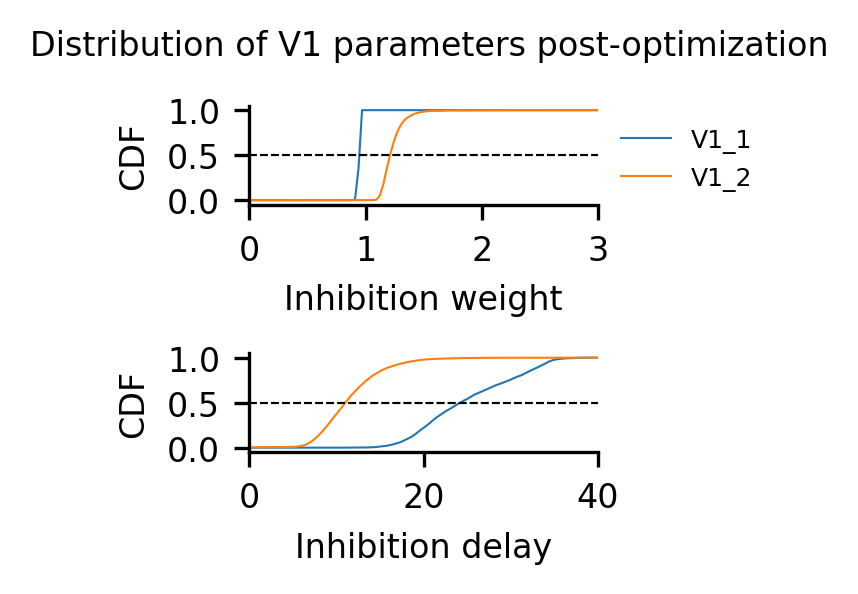

In [19]:
fig, ax = plt.subplots(2,1, figsize = (1.5, 1.5))

for i in range(2):
    i_ = np.abs(i-1)
    for u in range(2):
        x = np.linspace(
            list(param_bounds.values())[-1-i][0],
            list(param_bounds.values())[-1-i][1],
            100
        )
        data = param_history['V1_params'][:,-1,u,0,i_,0,0]
        kde = ecdf(data).cdf
        y = kde.evaluate(x)

        ax[i].plot(x,y, label = f'V1_{u+1}', linewidth = linewidth)
        ax[i].plot(x, np.full(len(x), 0.5), '--', color = 'black', linewidth = linewidth)
        ax[i].set_xlim(
            list(param_bounds.values())[-1-i][0],
            list(param_bounds.values())[-1-i][1]
        )
        ax[i].set_ylabel("CDF", fontsize = fontsize)
        ax[i].set_yticks(np.arange(0, 1.5, 0.5))
        ax[i].spines['top'].set_visible(False)
        ax[i].spines['right'].set_visible(False)
        ax[i].tick_params(labelsize = fontsize)

ax[0].set_xlabel('Inhibition weight', fontsize = fontsize)
ax[1].set_xlabel('Inhibition delay', fontsize = fontsize)
ax[0].legend(fontsize = 6, frameon = False, bbox_to_anchor = (1,1))
fig.subplots_adjust(hspace=1.5)
plt.suptitle("Distribution of V1 parameters post-optimization", fontsize = fontsize, x = 0.525, y = 1.05)

# figname = 'v1_parameter_dist_best_perm_opt.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

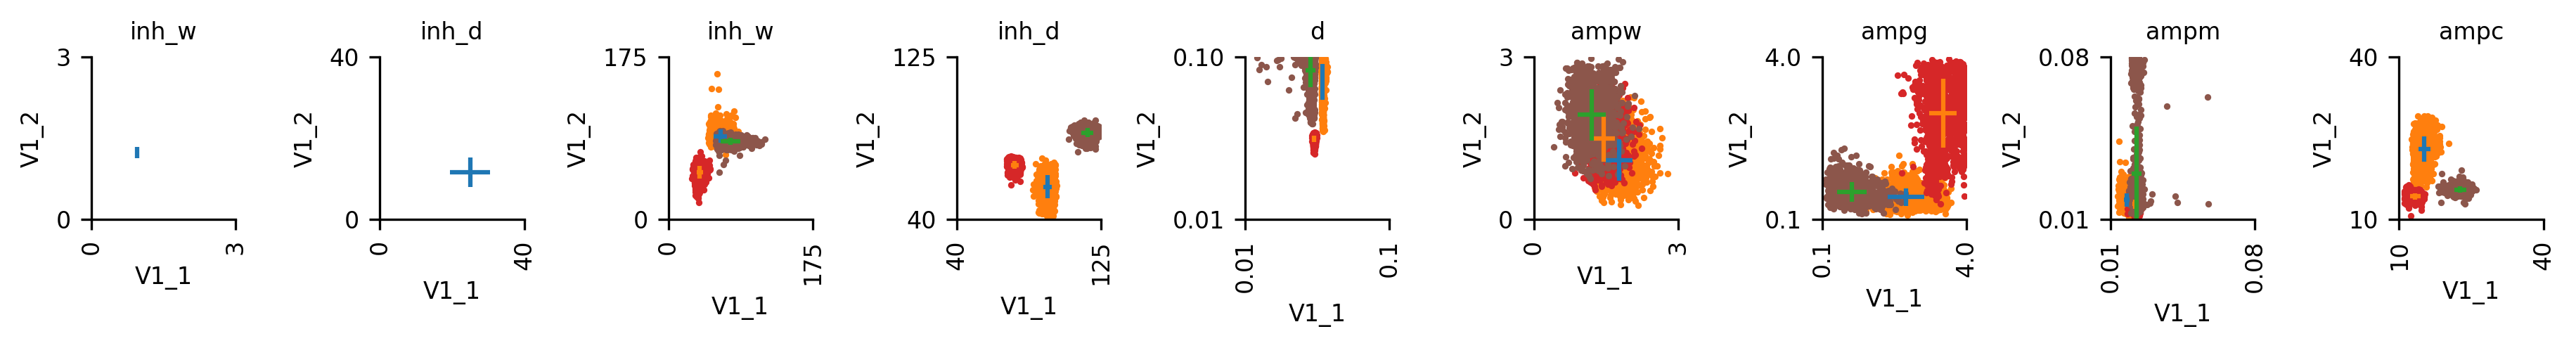

In [20]:
fig, ax = plt.subplots(1,9, figsize = (15,1))

for i in range(9):
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].tick_params(labelsize = fontsize)
for p in range(2,9):
    for i in range(3):
        x = param_history['dLGN_params'][lsi[:1000],-1,0,i,p-2,0,0].astype(np.float32)
        y = param_history['dLGN_params'][lsi[:1000],-1,1,i,p-2,0,0].astype(np.float32)

        ax[p].scatter(x.mean(0),y.mean(0), s = 5, linewidth = 0)
        ax[p].scatter(x,y, s = 5, linewidth = 0)
        
        lower, upper = param_bounds[list(param_bounds.keys())[p-2]]
        ax[p].set_ylim(lower, upper)
        ax[p].set_xlim(lower, upper)
        ax[p].set_xticks(np.array([lower, upper]).round(2))
        ax[p].set_xticklabels(np.array([lower, upper]).round(2), rotation = 90)
        ax[p].set_yticks(np.array([lower, upper]).round(2))
        ax[p].set_title(list(param_bounds.keys())[::-1][p-2], fontsize = fontsize)
        ax[p].set_ylabel("V1_2", fontsize = fontsize)
        ax[p].set_xlabel("V1_1", fontsize = fontsize)
        
        ax[p].errorbar(
            x.mean(0),y.mean(0),
            xerr = x.std(0),
            yerr = y.std(0)
        )
for p in range(2):
    i_ = np.abs(p-1)
    x = param_history['V1_params'][:,-1,0,0,i_,0,0].astype(np.float32)
    y = param_history['V1_params'][:,-1,1,0,i_,0,0].astype(np.float32)
    ax[p].errorbar(
        x.mean(0),y.mean(0),
        xerr = x.std(0),
        yerr = y.std(0)
    )
    ax[p].set_ylim(0,y.max())
    ax[p].set_xlim(0,y.max())

    lower, upper = param_bounds[list(param_bounds.keys())[::-1][p]]
    ax[p].set_title(list(param_bounds.keys())[::-1][p], fontsize = fontsize)
    ax[p].set_ylabel("V1_2", fontsize = fontsize)
    ax[p].set_xlabel("V1_1", fontsize = fontsize)
    ax[p].set_xticks(np.array([lower, upper]).round(2))
    ax[p].set_xticklabels(np.array([lower, upper]).round(2), rotation = 90)
    ax[p].set_yticks(np.array([lower, upper]).round(2))

plt.subplots_adjust(wspace=1)

# figname = 'param_dist_scatterstyle.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

In [21]:
from matplotlib.patches import Ellipse

def eigsorted(cov):
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    return vals[order], vecs[:,order]

def confidence_ellipse(data, n_std = 2, edgecolor = 'none', facecolor = 'none'):
    center = data.mean(0)
    cov = np.cov(data, rowvar=False)
    
    vals, vecs = eigsorted(cov)
    angle = np.degrees(np.arctan2(*vecs[:,0][::-1]))

    # Width and height are "full" widths, not radius
    width, height = 2 * n_std * np.sqrt(vals)
    ellip = Ellipse(xy=center, width=width, height=height, angle=angle, edgecolor = edgecolor, facecolor = facecolor)
    return ellip, center, width, height, angle

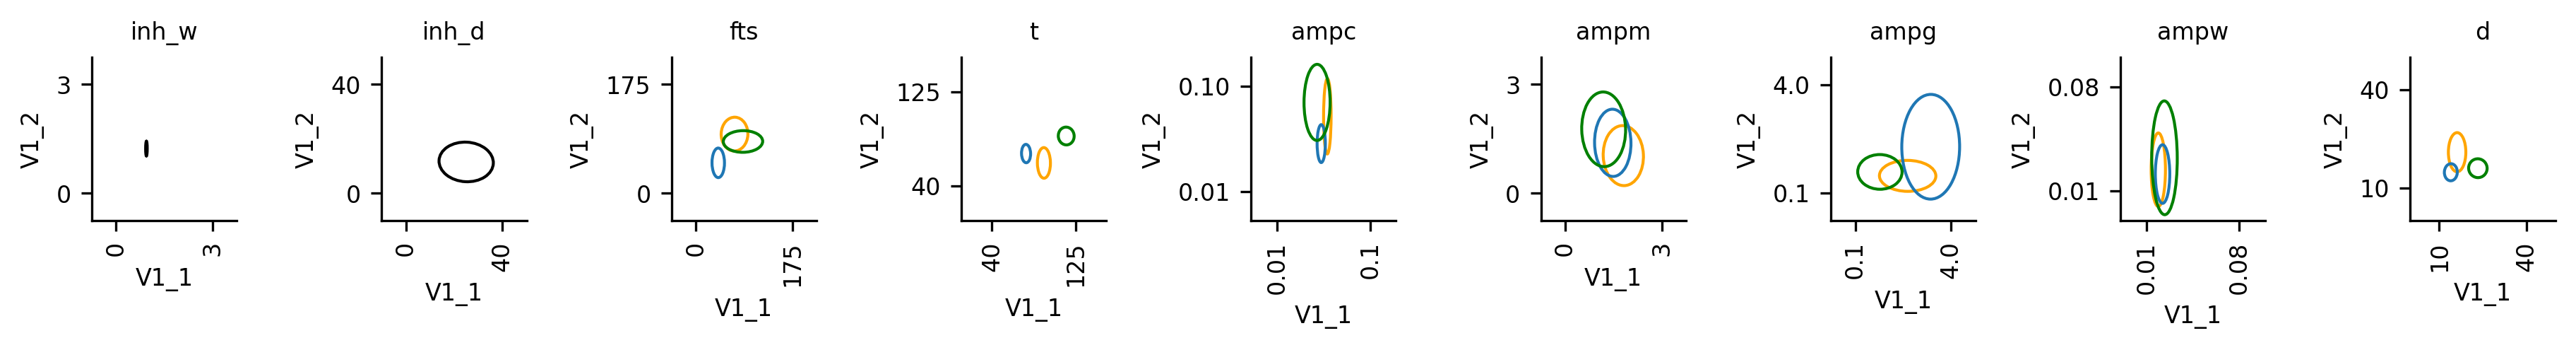

In [22]:
fig, ax = plt.subplots(1,9, figsize = (15,1))

for i in range(9):
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].tick_params(labelsize = fontsize)

color = ['orange', 'tab:blue', 'green']
for p in range(2,9):
    for i in range(3):
        data = param_history['dLGN_params'][:,-1,:,i,p-2,0,0].astype(np.float32)
        e = confidence_ellipse(data, n_std=2, edgecolor=color[i])
        ax[p].add_patch(e[0])
        
        lower, upper = param_bounds[list(param_bounds.keys())[p-2]]
        ax[p].set_ylim(lower-upper*0.25, upper+upper*0.25)
        ax[p].set_xlim(lower-upper*0.25, upper+upper*0.25)
        ax[p].set_xticks(np.array([lower, upper]).round(2))
        ax[p].set_xticklabels(np.array([lower, upper]).round(2), rotation = 90)
        ax[p].set_yticks(np.array([lower, upper]).round(2))
        ax[p].set_title(list(param_bounds.keys())[p-2], fontsize = fontsize)
        ax[p].set_ylabel("V1_2", fontsize = fontsize)
        ax[p].set_xlabel("V1_1", fontsize = fontsize)
        
for p in range(2):
    i_ = np.abs(p-1)
    data = param_history['V1_params'][:,-1,:,0,i_,0,0].astype(np.float32)
    e = confidence_ellipse(data, n_std=2, edgecolor='black')
    ax[p].add_patch(e[0])

    lower, upper = param_bounds[list(param_bounds.keys())[::-1][p]]
    ax[p].set_ylim(lower-upper*0.25, upper+upper*0.25)
    ax[p].set_xlim(lower-upper*0.25, upper+upper*0.25)
    ax[p].set_title(list(param_bounds.keys())[::-1][p], fontsize = fontsize)
    ax[p].set_ylabel("V1_2", fontsize = fontsize)
    ax[p].set_xlabel("V1_1", fontsize = fontsize)
    ax[p].set_xticks(np.array([lower, upper]).round(2))
    ax[p].set_xticklabels(np.array([lower, upper]).round(2), rotation = 90)
    ax[p].set_yticks(np.array([lower, upper]).round(2))

plt.subplots_adjust(wspace=1)

# figname = 'param_dist_scatterstyle.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

In [27]:
data.shape

(4000, 2)

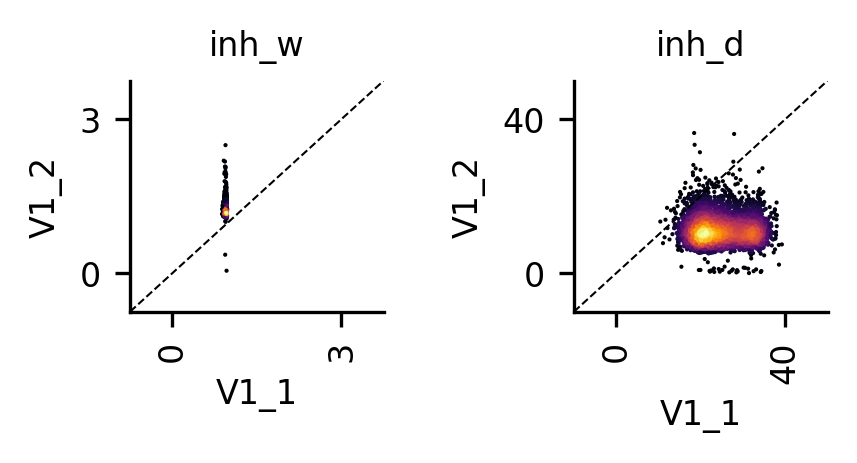

In [47]:
fig, ax = plt.subplots(1,2, figsize = (3,1))
for i in range(2):
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].tick_params(labelsize = fontsize)
for p in range(2):
    i_ = np.abs(p-1)
    data = param_history['V1_params'][:,-1,:,0,i_,0,0].astype(np.float32)
    kde = gaussian_kde(data.T)
    density = kde(data.T)
    cmap = plt.get_cmap('inferno')(minmax_norm(density, 0, 1))
    ax[p].scatter(*data.T, s = 1, color = cmap, linewidth = 0, rasterized = True)
    lower, upper = param_bounds[list(param_bounds.keys())[::-1][p]]
    ax[p].plot(
        np.linspace(lower-upper*0.25, upper+upper*0.25, 100), 
        np.linspace(lower-upper*0.25, upper+upper*0.25, 100), 
        '--', linewidth = 0.5, color = 'blacK'
    )

    ax[p].set_ylim(lower-upper*0.25, upper+upper*0.25)
    ax[p].set_xlim(lower-upper*0.25, upper+upper*0.25)
    ax[p].set_title(list(param_bounds.keys())[::-1][p], fontsize = fontsize)
    ax[p].set_ylabel("V1_2", fontsize = fontsize)
    ax[p].set_xlabel("V1_1", fontsize = fontsize)
    ax[p].set_xticks(np.array([lower, upper]).round(2))
    ax[p].set_xticklabels(np.array([lower, upper]).round(2), rotation = 90)
    ax[p].set_yticks(np.array([lower, upper]).round(2))

plt.subplots_adjust(wspace=0.75)

Text(0.525, 0.975, 'Distribution of dLGN parameters post-optimization')

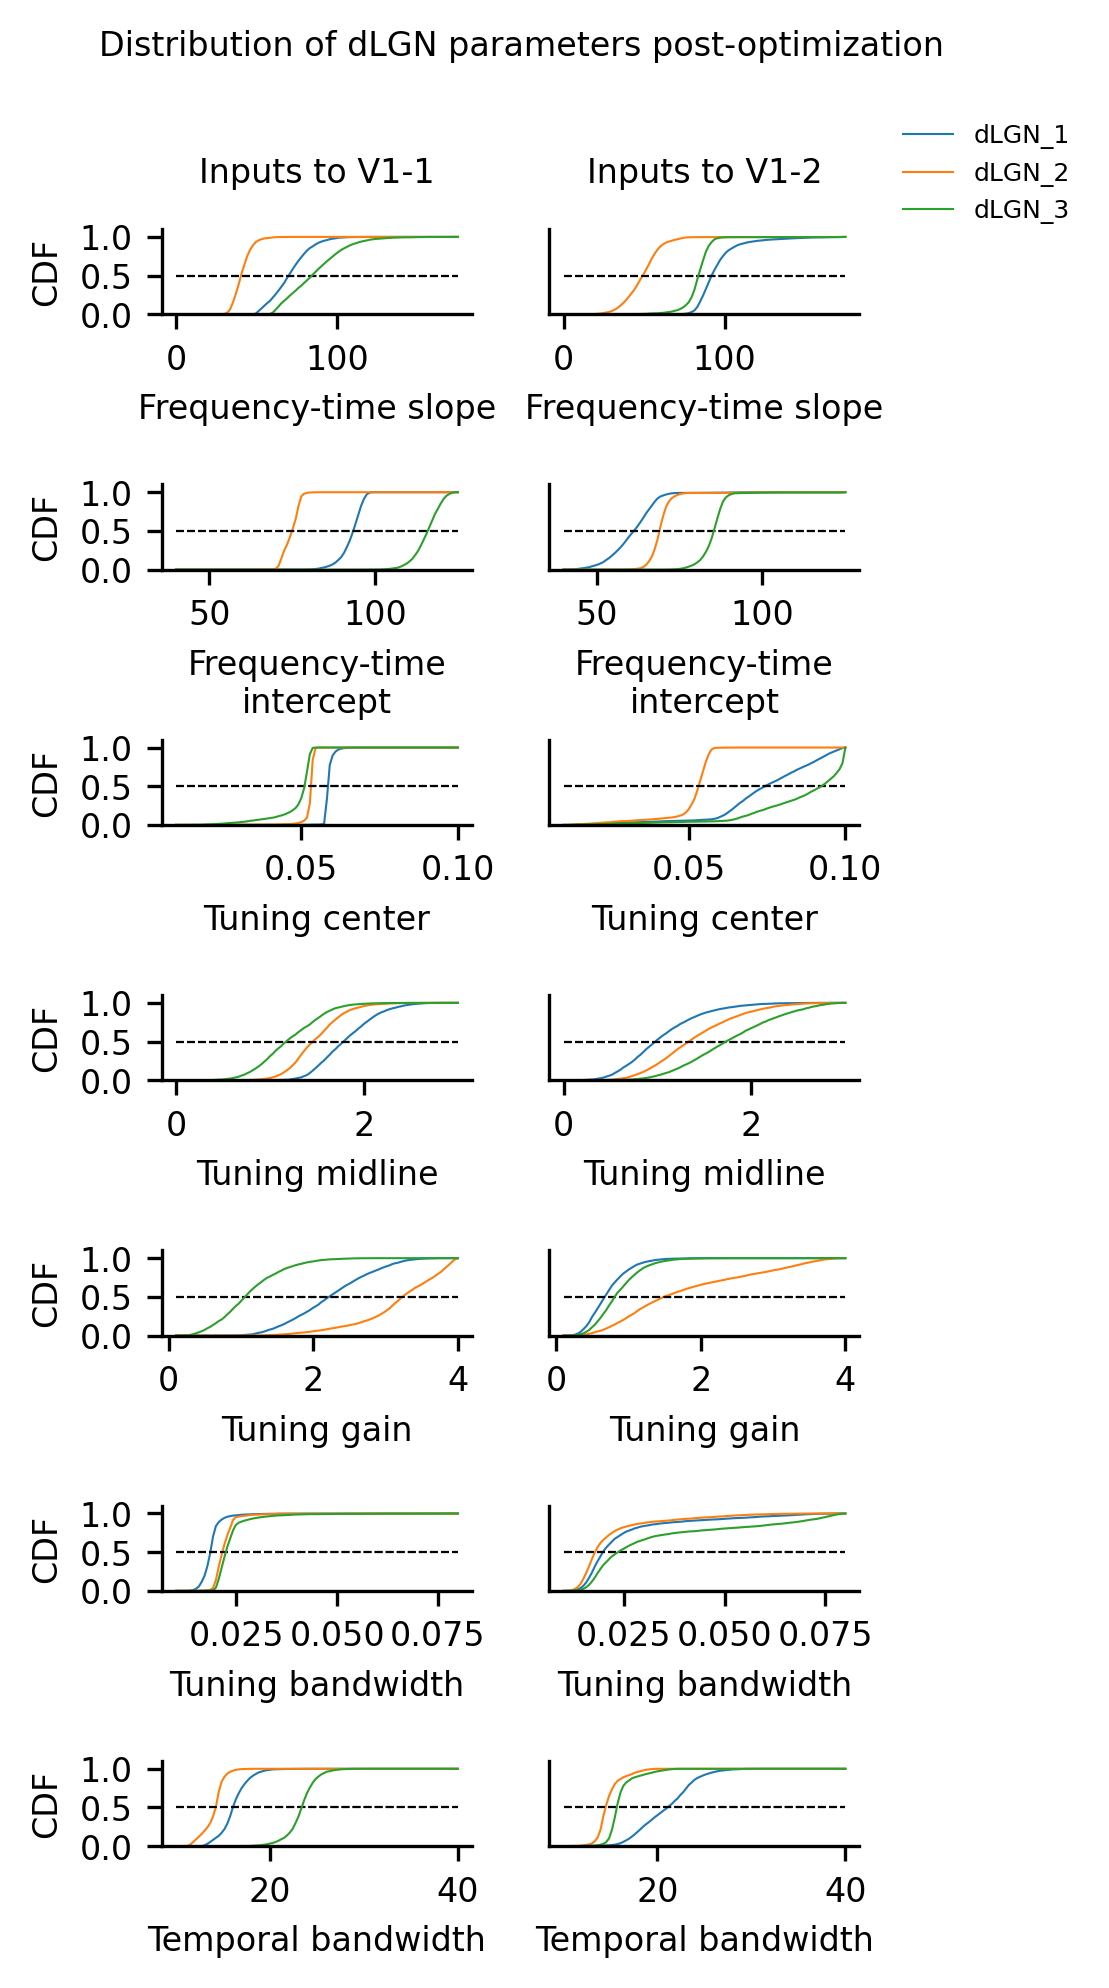

In [24]:
fig, ax = plt.subplots(7,2, figsize = (3,7))

param_labels = [
    'Frequency-time slope',
    'Frequency-time\nintercept',
    'Tuning center',
    'Tuning midline',
    'Tuning gain',
    'Tuning bandwidth',
    'Temporal bandwidth'
]

neuron_labels = [f'dLGN_{i+1}' for i in range(3)]


for row in range(7):
    ymax = []
    for u in range(2):
        data = param_history['dLGN_params'][:,-1,u,:,row,0,0].T.astype(np.float32)
        for i in range(3):
            data = param_history['dLGN_params'][:,-1,u,i,row,0,0]
            x = np.linspace(
                list(param_bounds.values())[:7][row][0],
                list(param_bounds.values())[:7][row][1], 
                100
            )
            kde = ecdf(data).cdf
            y = kde.evaluate(x)

            ymax.append(y.max())

            ax[row, u].plot(x, np.full(len(x), 0.5), '--', color = 'black', linewidth = linewidth)
            ax[row, u].plot(x, y, label = neuron_labels[i], linewidth = linewidth)
            ax[row, u].set_xlabel(param_labels[row], fontsize = fontsize)
            ax[row, u].tick_params(labelsize = fontsize)

        

    ax[row, 0].set_ylabel("CDF", fontsize = fontsize)
    for u in range(2):
        ax[row, u].set_ylim(0, 1.1)
        ax[row, 1].set_yticks([])
        ax[row, 0].set_yticks(np.arange(0, 1.5, 0.5))
        ax[row, u].spines['top'].set_visible(False)
        ax[row, u].spines['right'].set_visible(False)

fig.subplots_adjust(hspace = 2, wspace=0.25)
plt.tick_params(labelsize = 8)
ax[0,1].legend(fontsize = 6, bbox_to_anchor = (1.75,2.5), frameon = False)
ax[0,0].set_title("Inputs to V1-1", fontsize = fontsize, y = 1.25)
ax[0,1].set_title("Inputs to V1-2", fontsize = fontsize, y = 1.25)
plt.suptitle("Distribution of dLGN parameters post-optimization", fontsize = fontsize, x = 0.525, y = 0.975)

# figname = 'dlgn_param_ecdf_top_best_perm.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

In [32]:
u = param_history['dLGN_params'][:,-1,:,:,:,0,0].astype(np.float32).mean(0)
e = param_history['dLGN_params'][:,-1,:,:,:,0,0].astype(np.float32).std(0)

In [326]:
t_u = u[:,:,:2]
a_u = u[:,:,2:-1]

In [327]:
t_u

array([[[ 70.44861 ,  92.83959 ],
        [ 40.95162 ,  74.676544],
        [ 85.77898 , 115.55803 ]],

       [[ 95.04045 ,  60.717037],
        [ 48.86272 ,  69.17224 ],
        [ 83.19141 ,  85.02126 ]]], dtype=float32)

In [ ]:
param_bounds = {
    "fts": [0, 175],
    "t": [40, 125],
    "ampc": [0.01, 0.1],
    'ampm': [0,3],
    "ampg": [0.1, 4],
    "ampw": [0.01,0.08],
    "d": [10, 40],
    "inh_d": [0, 40],
    "inh_w": [0, 3],
}

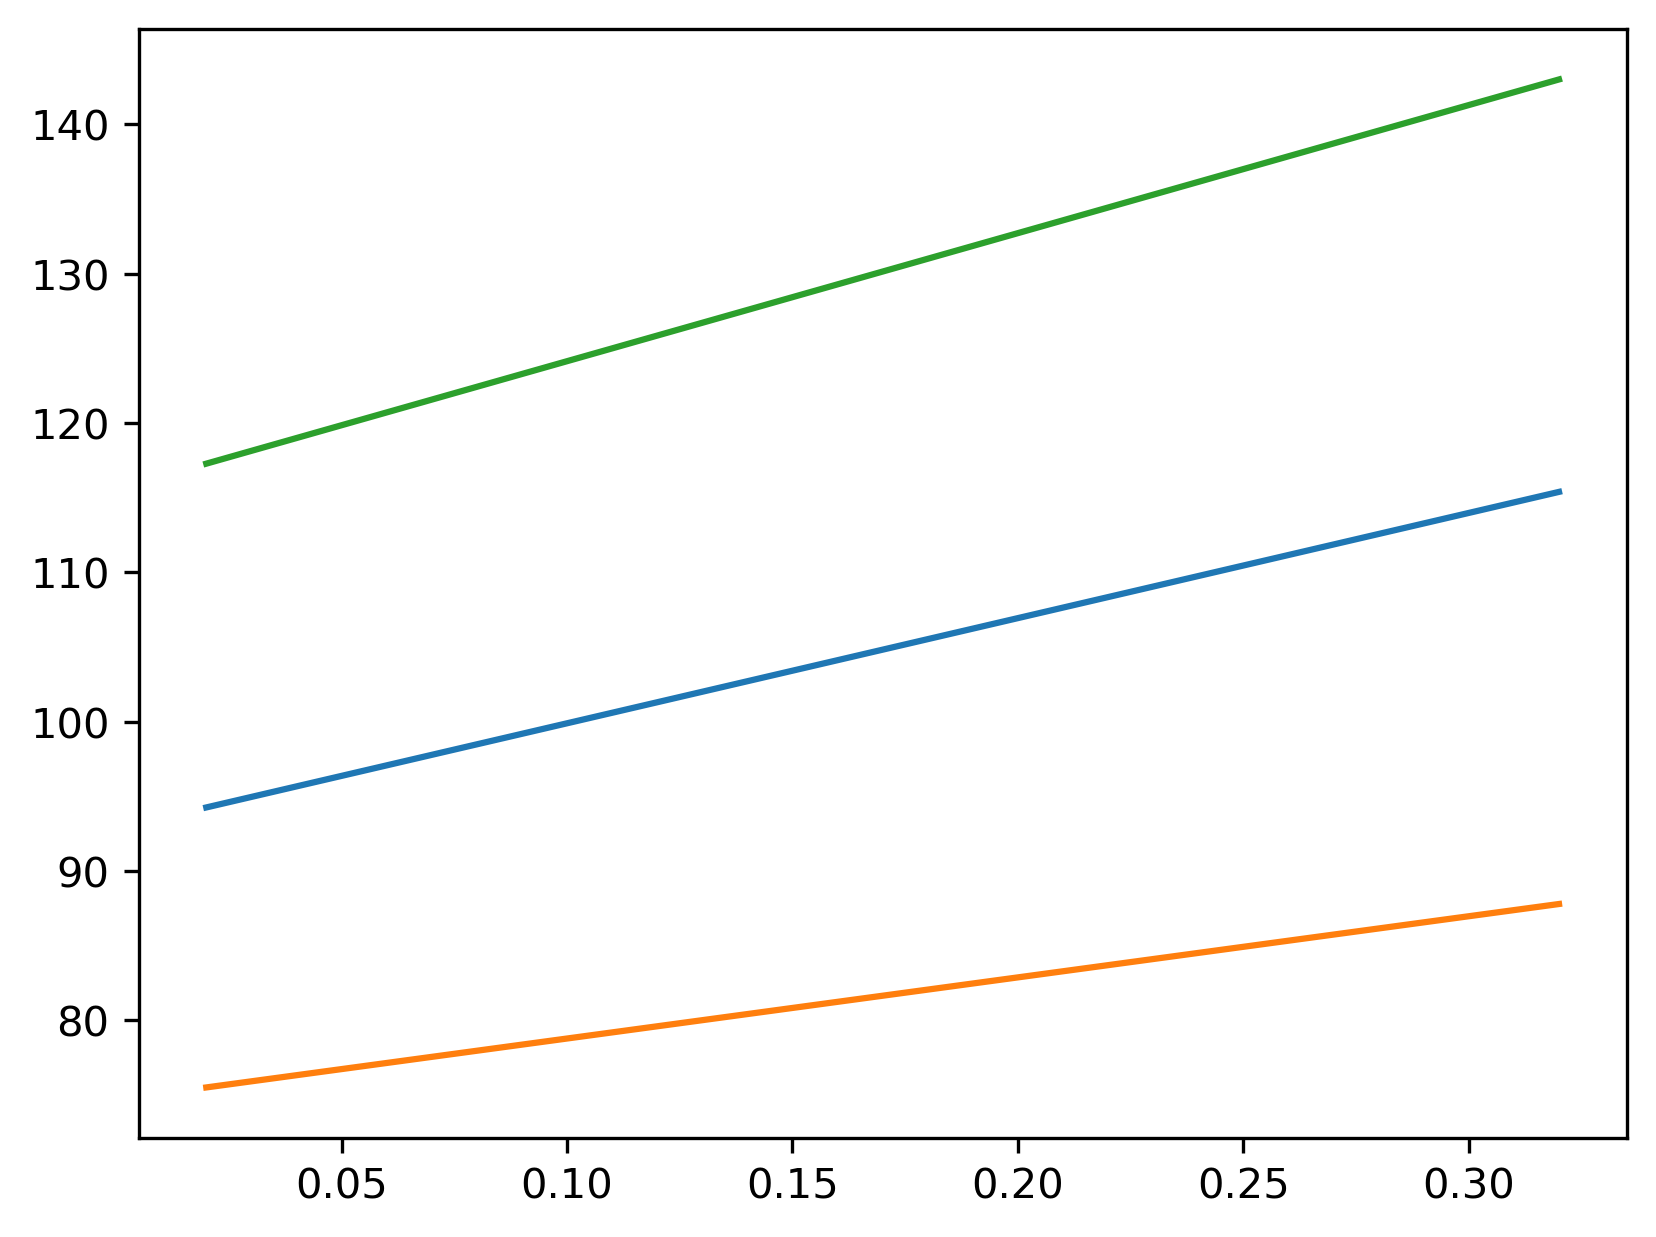

In [66]:
plt.plot(X, ft_u[0,0])
plt.plot(X, ft_u[0,1])
plt.plot(X, ft_u[0,2])

In [395]:
Z[:,0].max()

2.0316963

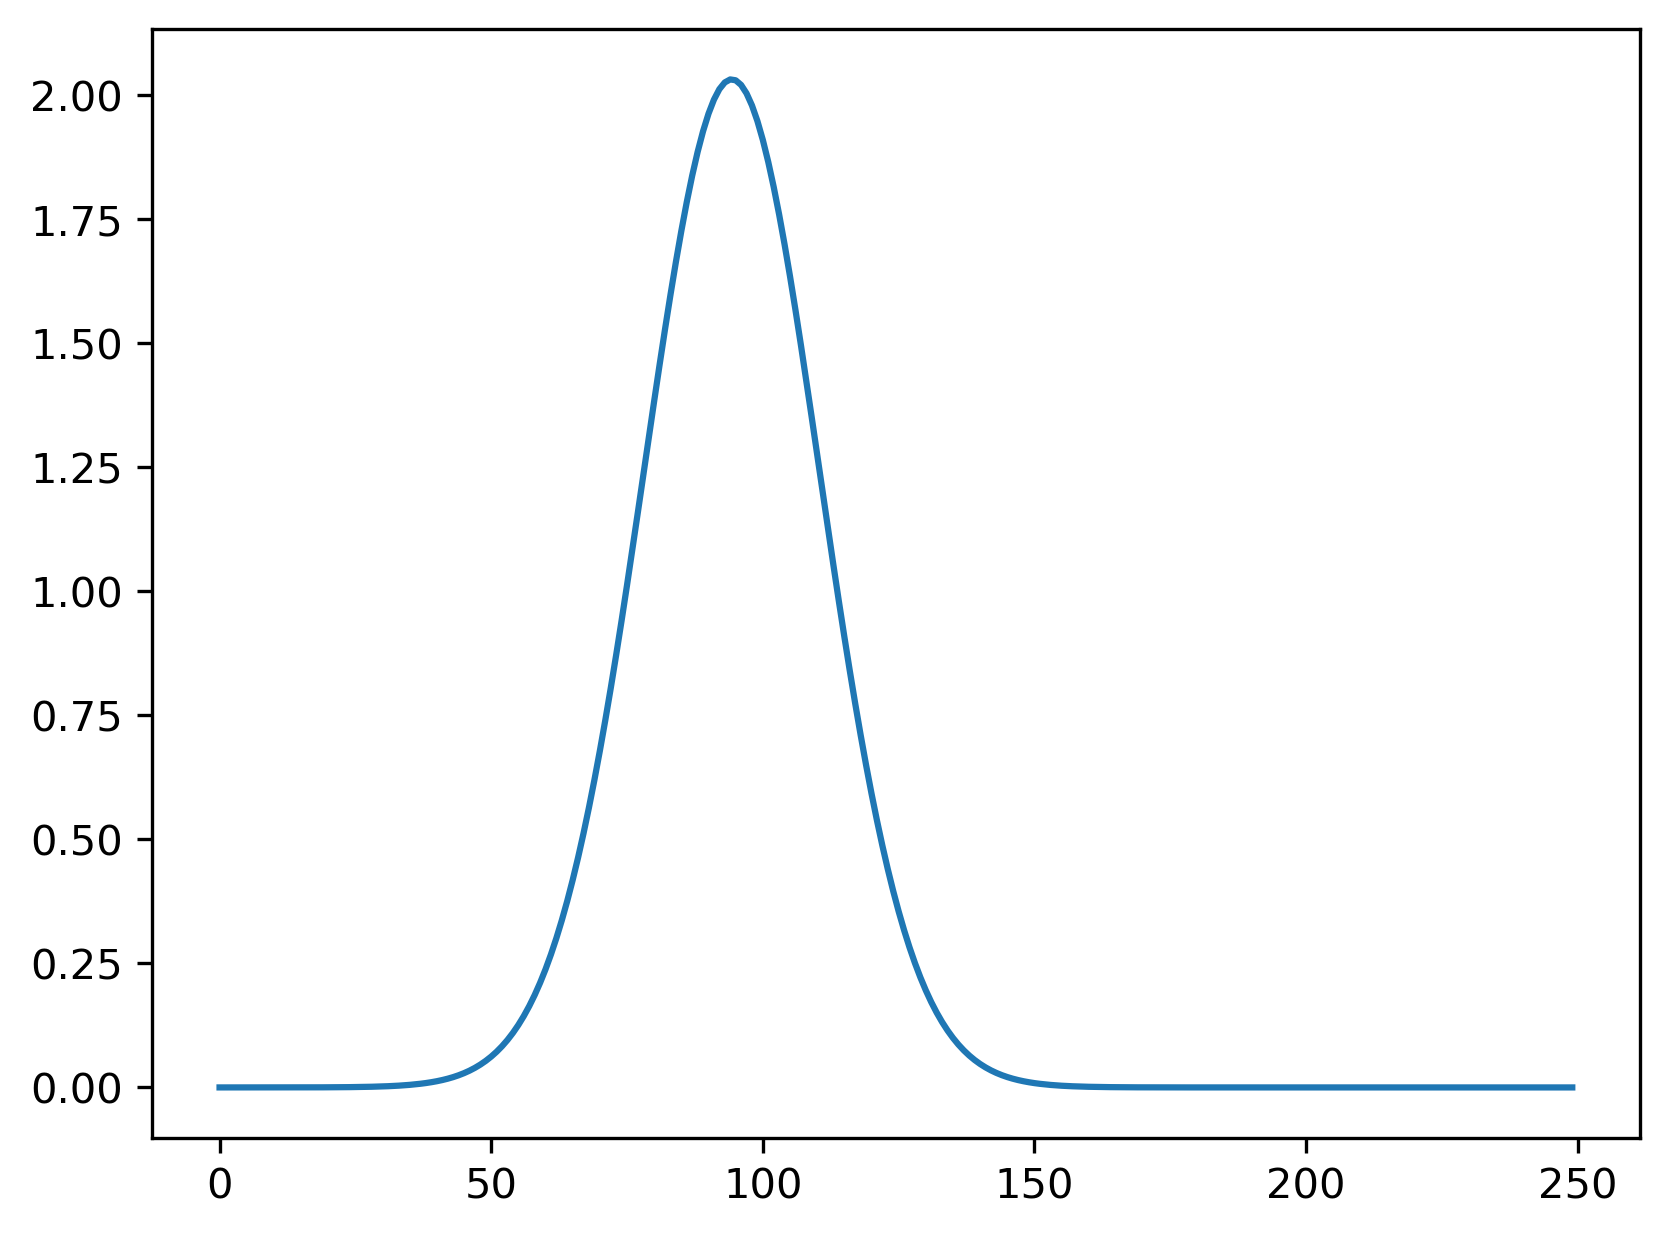

In [ ]:
plt.plot(Z[:,0])

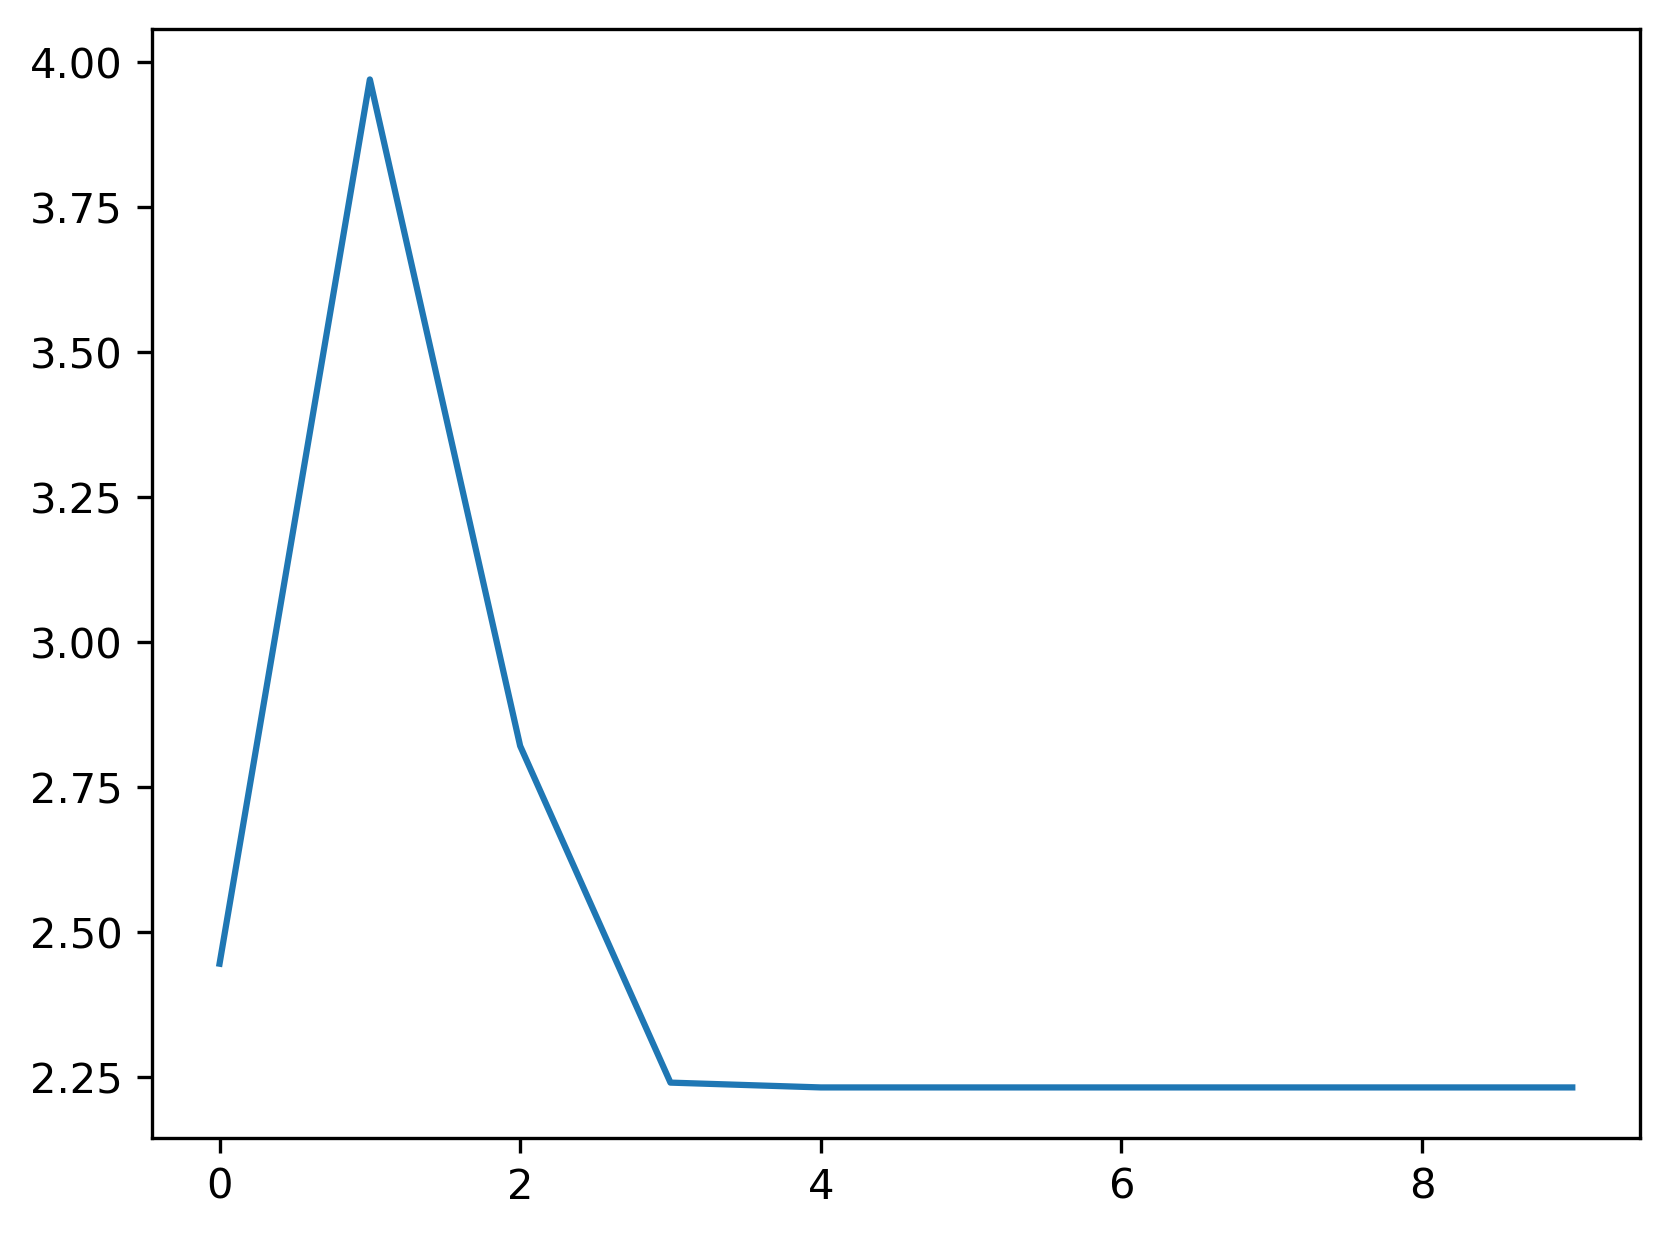

In [393]:
plt.plot(gaussian(np.linspace(0.02,0.32,10), *a_u[0,0]))

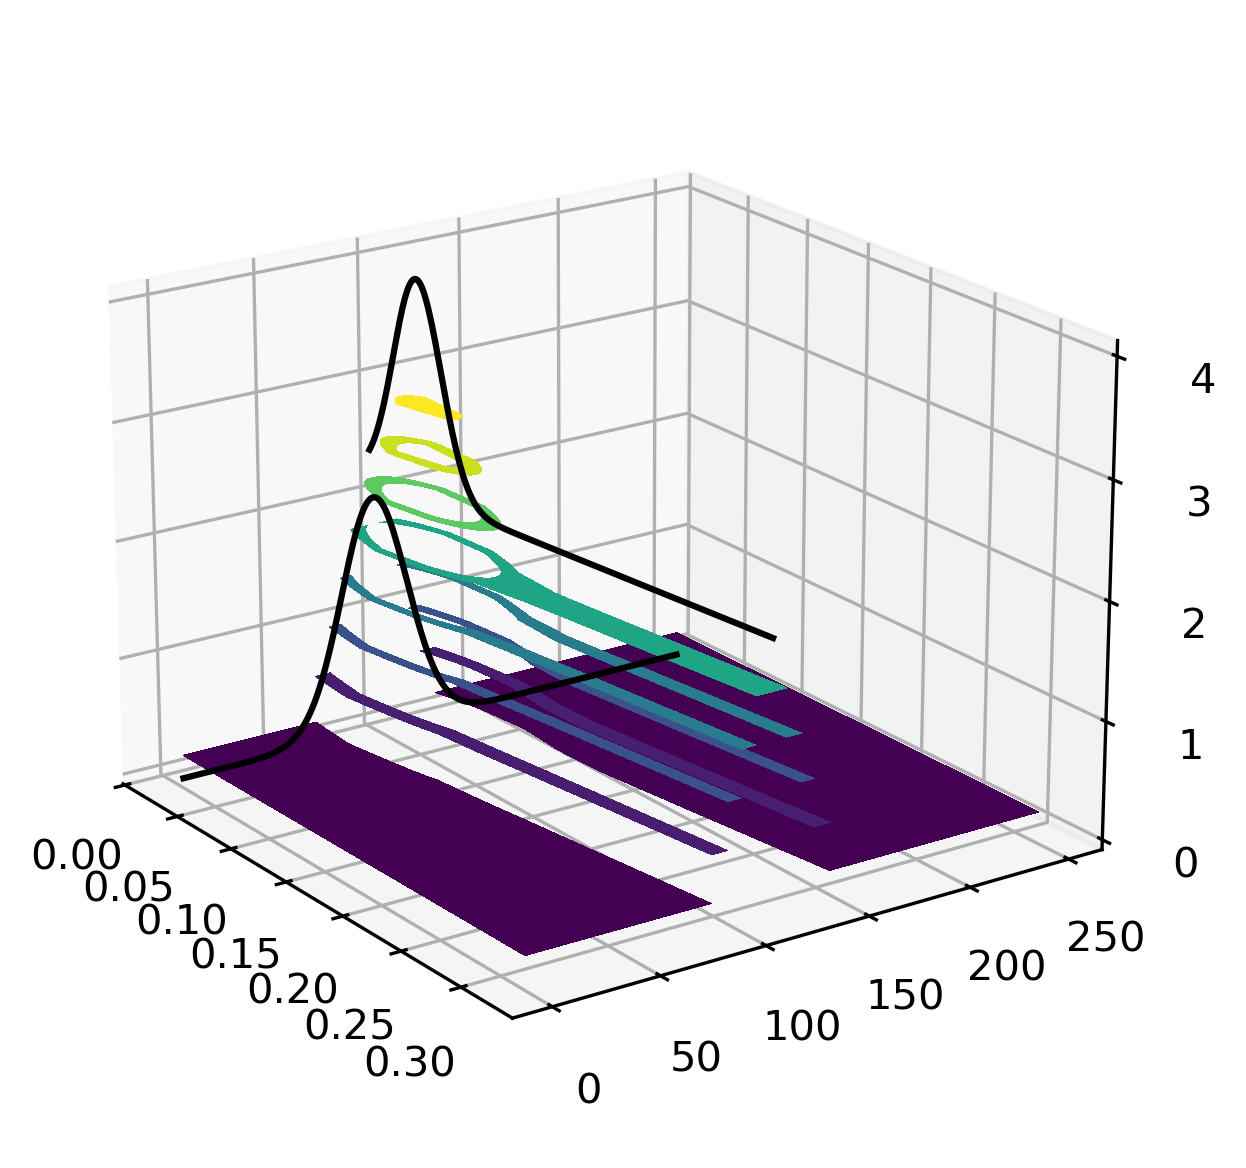

In [392]:
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import axes3d

ax = plt.figure().add_subplot(projection='3d')
x = np.linspace(0.02, 0.32, 10)#X.numpy()  # SF values, shape (n_sf,)
y = np.arange(250)  # time points
X_,Y = np.meshgrid(x,y)

Z = sgcc.dlgn_exc.numpy().mean(0)[0, 0].T  # shape (n_sf, 250)
ax.contourf(X_, Y, Z, zdir='z', zorder = 0, extend = 'both')
ft_uexp = t_u[:,:,0:1] * np.linspace(0,0.32,250) + t_u[:,:,1:]
ax.plot(
    np.linspace(0.02,0.32,250), 
    ft_uexp[0,0], 
    gaussian(np.linspace(0.02,0.32,250), *a_u[0,0]),
    zorder = 3, color = 'black'
)

ax.plot(
    np.full(250, 0.02), 
    y, 
    Z[:,0],
    zorder = 3, color = 'black'
)


ax.view_init(elev=20, azim=-35)

Text(0.5, 1.15, 'Convergence of V1 parameter values')

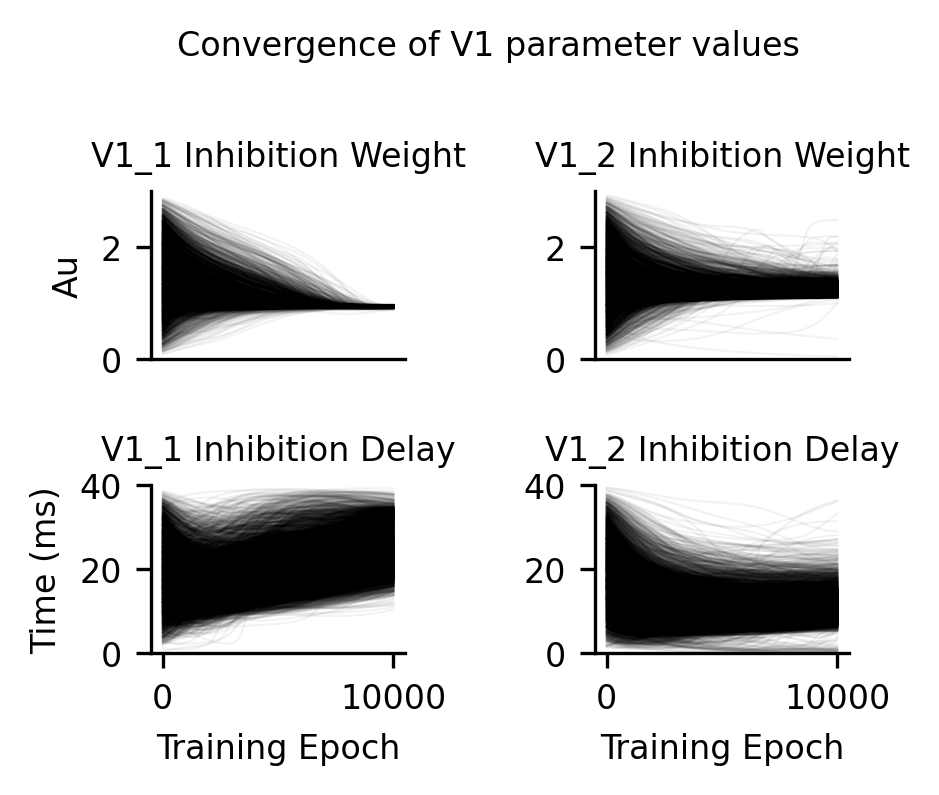

In [19]:
## inhibition weight::inhibition delay

fig, ax = plt.subplots(2,2, figsize = (3,2))

inh_w = 1
v1_n = 0 

for row in range(2):
    for col in range(2):
        ax[row, col].spines['top'].set_visible(False)
        ax[row, col].spines['right'].set_visible(False)
        ax[row, col].tick_params(labelsize = fontsize)

ax[0,0].plot(
    param_history['V1_params'][:,:,v1_n,0,inh_w,0,0].T,
    linewidth=linewidth,
    alpha=0.05,
    color = 'black'
)

# 
v1_n = 1
ax[0,1].plot(
    param_history['V1_params'][:,:,v1_n,0,inh_w,0,0].T,
    linewidth=linewidth,
    alpha=0.05,
    color = 'black'
)

# a0
inh_d = 0
v1_n = 0
ax[1,0].plot(
    param_history['V1_params'][:,:,v1_n,0,inh_d,0,0].T,
    linewidth=linewidth,
    alpha=0.05,
    color = 'black'
)

# a1
v1_n = 1
ax[1,1].plot(
    param_history['V1_params'][:,:,v1_n,0,inh_d,0,0].T,
    linewidth=linewidth,
    alpha=0.05,
    color = 'black'
)

ax[0,0].set_ylim(param_bounds['inh_w'][0], param_bounds['inh_w'][1])
ax[0,0].set_title("V1_1 Inhibition Weight", fontsize = fontsize)
ax[0,0].set_xticks([])
ax[0,0].set_ylabel("Au", fontsize = fontsize)

ax[0,1].set_ylim(param_bounds['inh_w'][0], param_bounds['inh_w'][1])
ax[0,1].set_title("V1_2 Inhibition Weight", fontsize = fontsize)
ax[0,1].set_xticks([])

ax[1,0].set_ylim(param_bounds['inh_d'][0], param_bounds['inh_d'][1])
ax[1,0].set_title("V1_1 Inhibition Delay", fontsize = fontsize)
ax[1,0].set_ylabel("Time (ms)", fontsize = fontsize)
ax[1,0].set_xlabel("Training Epoch", fontsize = fontsize)

ax[1,1].set_ylim(param_bounds['inh_d'][0], param_bounds['inh_d'][1])
ax[1,1].set_title("V1_2 Inhibition Delay", fontsize = fontsize)
ax[1,1].set_xlabel("Training Epoch", fontsize = fontsize)
fig.subplots_adjust(wspace=0.75, hspace=0.75)
plt.suptitle("Convergence of V1 parameter values", fontsize = fontsize, y = 1.15)

# figname = '2d_model_v1_param_convergence_first_round.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

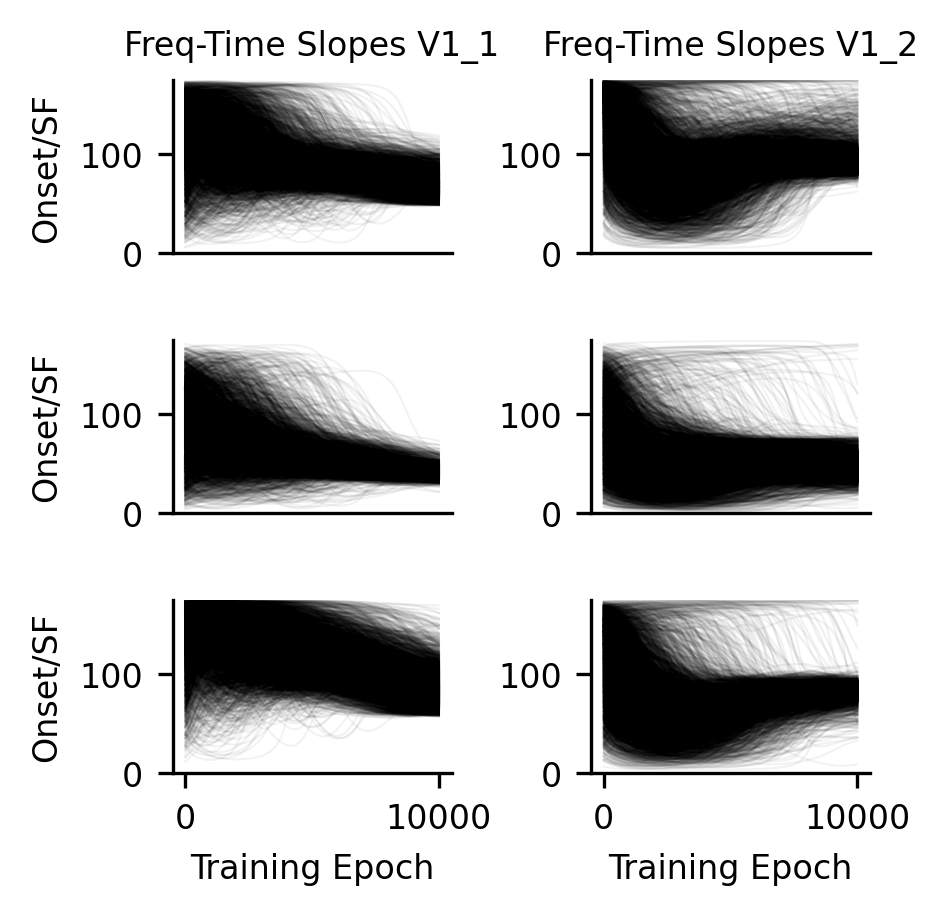

In [20]:
fig, ax = plt.subplots(3,2, figsize = (3,3))
norm = plt.Normalize(0, 1)

param = 0

for col in range(2):
    for row in range(3):

        ax[row, col].spines['top'].set_visible(False)
        ax[row, col].spines['right'].set_visible(False)
        ax[row, col].tick_params(labelsize = fontsize)

        data = param_history['dLGN_params'][:,:,col,row,param,0,0].T
        ax[row,col].plot(
        param_history['dLGN_params'][:,:,col,row,param,0,0].T,
            linewidth=linewidth,
            alpha=0.05,
            color='black'
        )

for i in range(2):
    ax[0,i].set_title(f"Freq-Time Slopes V1_{i+1}", fontsize = fontsize)
for i in range(3):
    ax[i,0].set_ylabel("Onset/SF", fontsize = fontsize)
for row in range(2):
    for col in range(2):
        ax[row,col].set_xticks([])
for row in range(3):
    for col in range(2):
        ax[row,col].set_ylim(param_bounds['fts'][0], param_bounds['fts'][1])
for i in range(2):
    ax[2,i].set_xlabel("Training Epoch", fontsize = fontsize)

fig.subplots_adjust(wspace=0.5, hspace=0.5)

# figname = '2d_model_fts_convergence_first_round.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

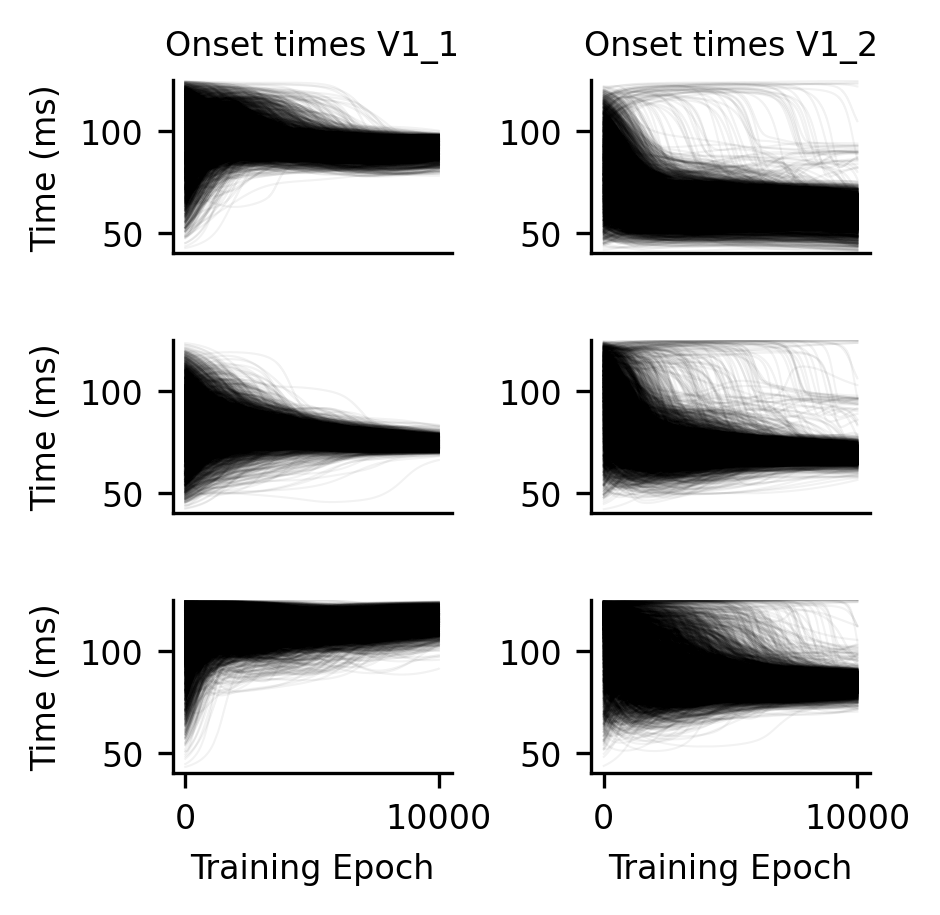

In [21]:
fig, ax = plt.subplots(3,2, figsize = (3,3))
norm = plt.Normalize(0, 1)

param = 1

for col in range(2):
    for row in range(3):

        ax[row, col].spines['top'].set_visible(False)
        ax[row, col].spines['right'].set_visible(False)
        ax[row, col].tick_params(labelsize = fontsize)

        data = param_history['dLGN_params'][:,:,col,row,param,0,0].T
        ax[row,col].plot(
        param_history['dLGN_params'][:,:,col,row,param,0,0].T,
            linewidth=linewidth,
            alpha=0.05,
            color='black'
        )

for i in range(2):
    ax[0,i].set_title(f"Onset times V1_{i+1}", fontsize = fontsize)
for i in range(3):
    ax[i,0].set_ylabel("Time (ms)", fontsize = fontsize)
for row in range(2):
    for col in range(2):
        ax[row,col].set_xticks([])
for row in range(3):
    for col in range(2):
        ax[row,col].set_ylim(param_bounds['t'][0], param_bounds['t'][1])
for i in range(2):
    ax[2,i].set_xlabel("Training Epoch", fontsize = fontsize)

fig.subplots_adjust(wspace=0.5, hspace=0.5)

# figname = '2d_model_t_convergence_first_round.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

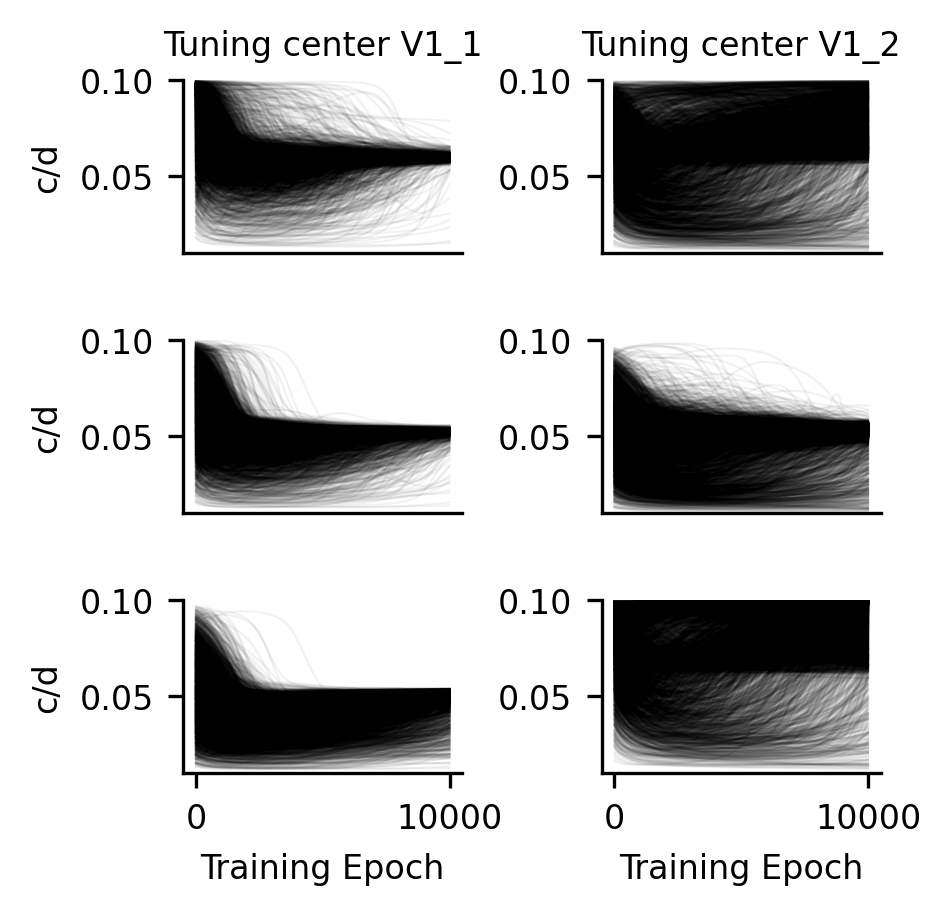

In [22]:
fig, ax = plt.subplots(3,2, figsize = (3,3))
norm = plt.Normalize(0, 1)

param = 2

for col in range(2):
    for row in range(3):

        ax[row, col].spines['top'].set_visible(False)
        ax[row, col].spines['right'].set_visible(False)
        ax[row, col].tick_params(labelsize = fontsize)

        data = param_history['dLGN_params'][:,:,col,row,param,0,0].T
        ax[row,col].plot(
        param_history['dLGN_params'][:,:,col,row,param,0,0].T,
            linewidth=linewidth,
            alpha=0.05,
            color='black'
        )

for i in range(2):
    ax[0,i].set_title(f"Tuning center V1_{i+1}", fontsize = fontsize)
for i in range(3):
    ax[i,0].set_ylabel("c/d", fontsize = fontsize)
for row in range(2):
    for col in range(2):
        ax[row,col].set_xticks([])
for row in range(3):
    for col in range(2):
        ax[row,col].set_ylim(param_bounds['ampc'][0], param_bounds['ampc'][1])
for i in range(2):
    ax[2,i].set_xlabel("Training Epoch", fontsize = fontsize)

fig.subplots_adjust(wspace=0.5, hspace=0.5)

# figname = '2d_model_ampc_convergence_first_round.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

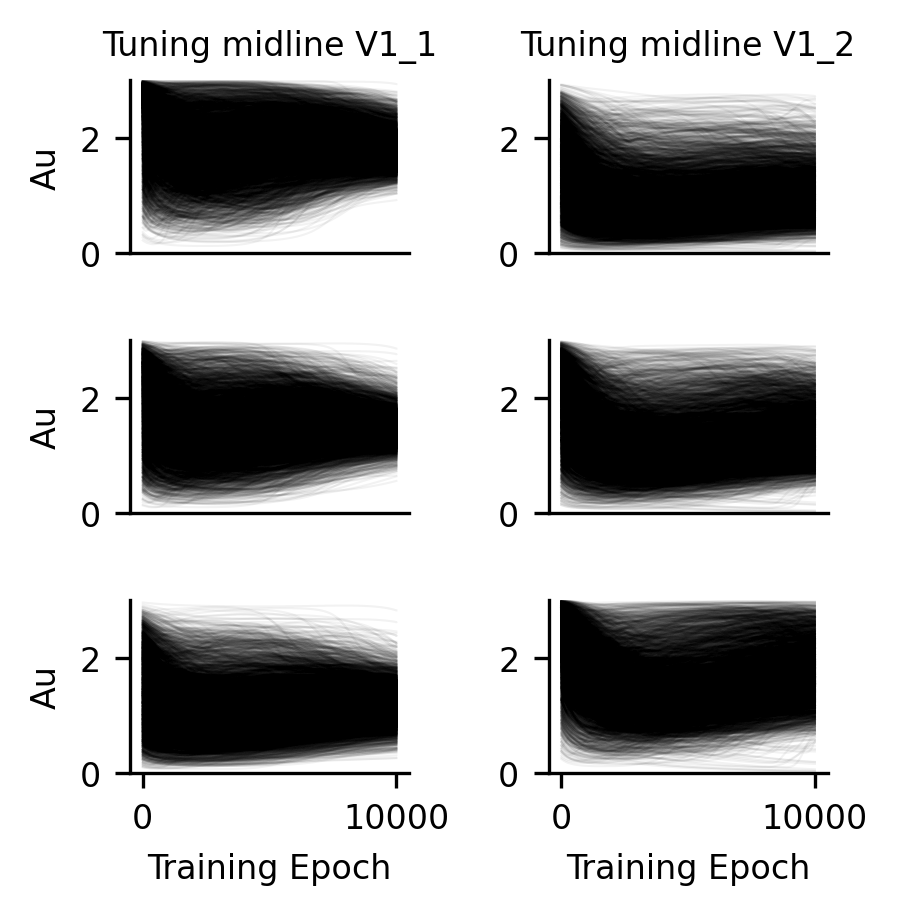

In [23]:
fig, ax = plt.subplots(3,2, figsize = (3,3))
norm = plt.Normalize(0, 1)

param = 3

for col in range(2):
    for row in range(3):

        ax[row, col].spines['top'].set_visible(False)
        ax[row, col].spines['right'].set_visible(False)
        ax[row, col].tick_params(labelsize = fontsize)

        data = param_history['dLGN_params'][:,:,col,row,param,0,0].T
        ax[row,col].plot(
        param_history['dLGN_params'][:,:,col,row,param,0,0].T,
            linewidth=linewidth,
            alpha=0.05,
            color='black'
        )

for i in range(2):
    ax[0,i].set_title(f"Tuning midline V1_{i+1}", fontsize = fontsize)
for i in range(3):
    ax[i,0].set_ylabel("Au", fontsize = fontsize)
for row in range(2):
    for col in range(2):
        ax[row,col].set_xticks([])
for row in range(3):
    for col in range(2):
        ax[row,col].set_ylim(param_bounds['ampm'][0], param_bounds['ampm'][1])
for i in range(2):
    ax[2,i].set_xlabel("Training Epoch", fontsize = fontsize)

fig.subplots_adjust(wspace=0.5, hspace=0.5)

# figname = '2d_model_ampm_convergence_first_round.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

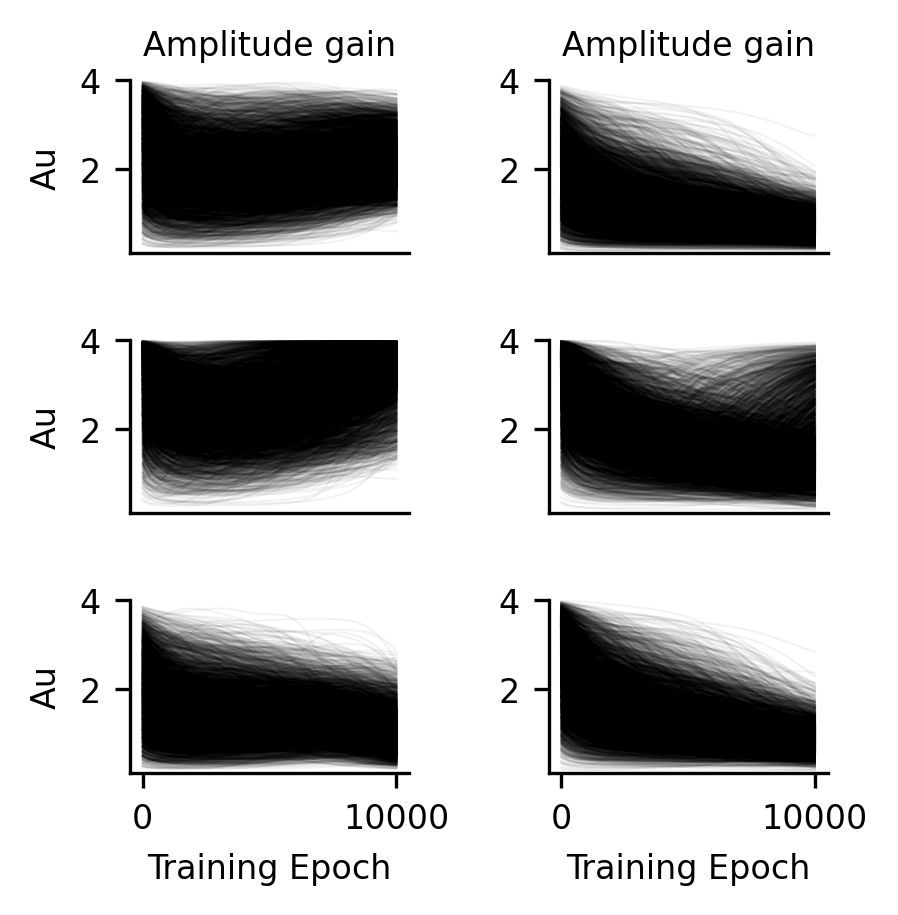

In [24]:
fig, ax = plt.subplots(3,2, figsize = (3,3))
norm = plt.Normalize(0, 1)

param = 4

for col in range(2):
    for row in range(3):

        ax[row, col].spines['top'].set_visible(False)
        ax[row, col].spines['right'].set_visible(False)
        ax[row, col].tick_params(labelsize = fontsize)

        data = param_history['dLGN_params'][:,:,col,row,param,0,0].T
        ax[row,col].plot(
        param_history['dLGN_params'][:,:,col,row,param,0,0].T,
            linewidth=linewidth,
            alpha=0.05,
            color='black'
        )

for i in range(2):
    ax[0,i].set_title(f"Amplitude gain", fontsize = fontsize)
for i in range(3):
    ax[i,0].set_ylabel("Au", fontsize = fontsize)
for row in range(2):
    for col in range(2):
        ax[row,col].set_xticks([])
for row in range(3):
    for col in range(2):
        ax[row,col].set_ylim(param_bounds['ampg'][0], param_bounds['ampg'][1])
for i in range(2):
    ax[2,i].set_xlabel("Training Epoch", fontsize = fontsize)

fig.subplots_adjust(wspace=0.5, hspace=0.5)

# figname = '2d_model_ampg_convergence_first_round.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

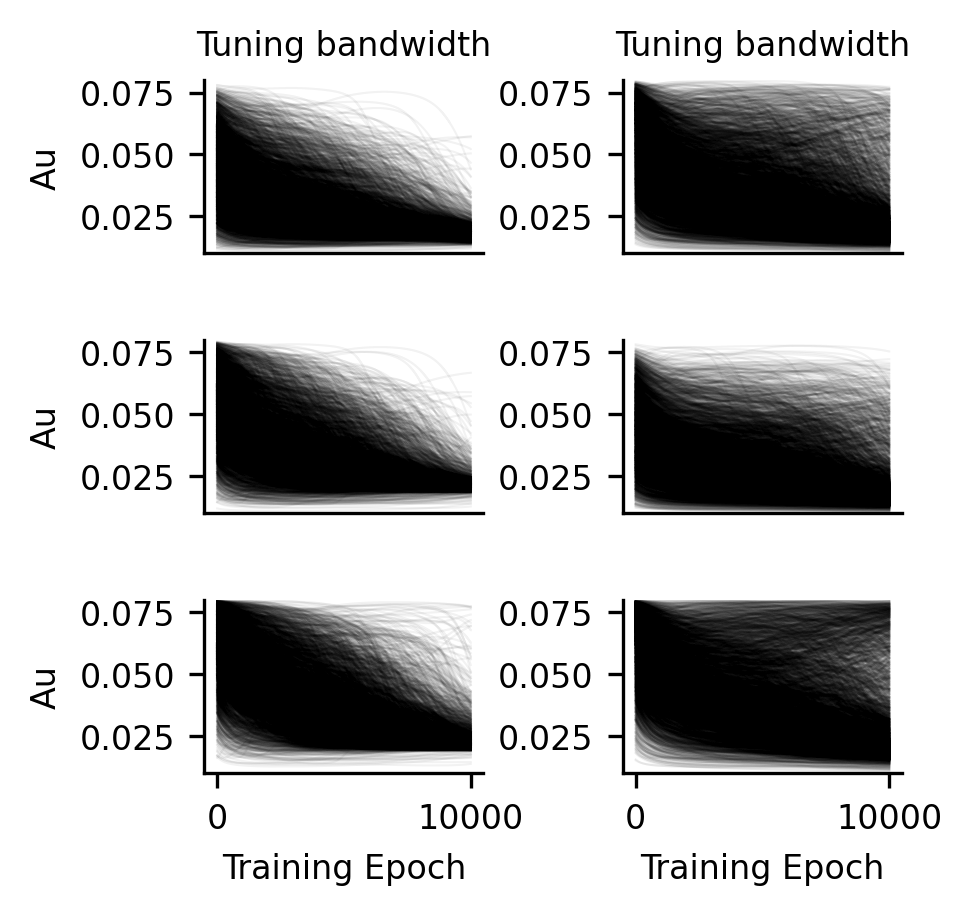

In [25]:
fig, ax = plt.subplots(3,2, figsize = (3,3))
norm = plt.Normalize(0, 1)

param = 5

for col in range(2):
    for row in range(3):

        ax[row, col].spines['top'].set_visible(False)
        ax[row, col].spines['right'].set_visible(False)
        ax[row, col].tick_params(labelsize = fontsize)

        data = param_history['dLGN_params'][:,:,col,row,param,0,0].T
        ax[row,col].plot(
        param_history['dLGN_params'][:,:,col,row,param,0,0].T,
            linewidth=linewidth,
            alpha=0.05,
            color='black'
        )

for i in range(2):
    ax[0,i].set_title(f"Tuning bandwidth", fontsize = fontsize)
for i in range(3):
    ax[i,0].set_ylabel("Au", fontsize = fontsize)
for row in range(2):
    for col in range(2):
        ax[row,col].set_xticks([])
for row in range(3):
    for col in range(2):
        ax[row,col].set_ylim(param_bounds['ampw'][0], param_bounds['ampw'][1])
for i in range(2):
    ax[2,i].set_xlabel("Training Epoch", fontsize = fontsize)

fig.subplots_adjust(wspace=0.5, hspace=0.5)

# figname = '2d_model_ampw_convergence_first_round.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

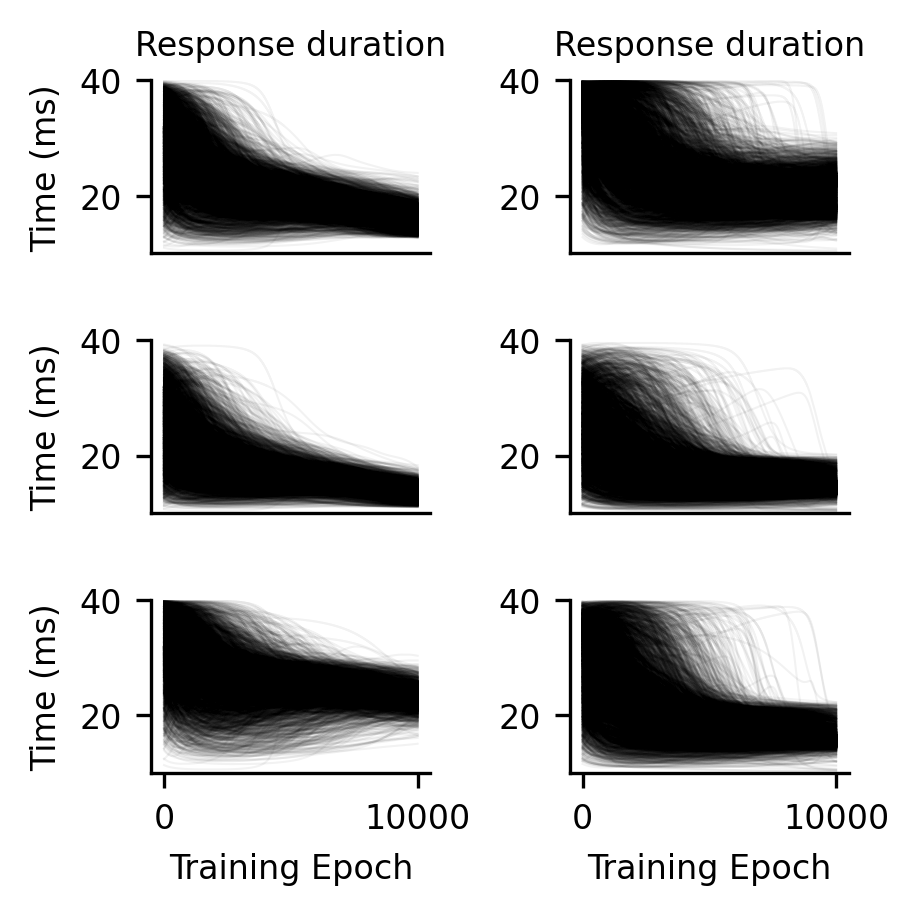

In [26]:
fig, ax = plt.subplots(3,2, figsize = (3,3))
norm = plt.Normalize(0, 1)

param = 6

for col in range(2):
    for row in range(3):

        ax[row, col].spines['top'].set_visible(False)
        ax[row, col].spines['right'].set_visible(False)
        ax[row, col].tick_params(labelsize = fontsize)

        data = param_history['dLGN_params'][:,:,col,row,param,0,0].T
        ax[row,col].plot(
        param_history['dLGN_params'][:,:,col,row,param,0,0].T,
            linewidth=linewidth,
            alpha=0.05,
            color='black'
        )

for i in range(2):
    ax[0,i].set_title(f"Response duration", fontsize = fontsize)
for i in range(3):
    ax[i,0].set_ylabel("Time (ms)", fontsize = fontsize)
for row in range(2):
    for col in range(2):
        ax[row,col].set_xticks([])
for row in range(3):
    for col in range(2):
        ax[row,col].set_ylim(param_bounds['d'][0], param_bounds['d'][1])
for i in range(2):
    ax[2,i].set_xlabel("Training Epoch", fontsize = fontsize)

fig.subplots_adjust(wspace=0.5, hspace=0.5)

# figname = '2d_model_d_convergence_first_round.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

In [27]:
res = param_history['dLGN_params'].squeeze()
print(res.shape[2:])
n_samples, n_epochs = res.shape[:2]
n_params = np.prod(res.shape[2:])# + np.prod(r2.shape[2:])

res = res.reshape(res.shape[0] * res.shape[1], np.prod(res.shape[2:]))

(2, 3, 7)


In [28]:
pca = PCA() # all epochs included
res_transformed_pca = pca.fit_transform(res).reshape(n_samples, n_epochs, n_params)

MemoryError: Unable to allocate 12.5 GiB for an array with shape (40000000, 42) and data type float64

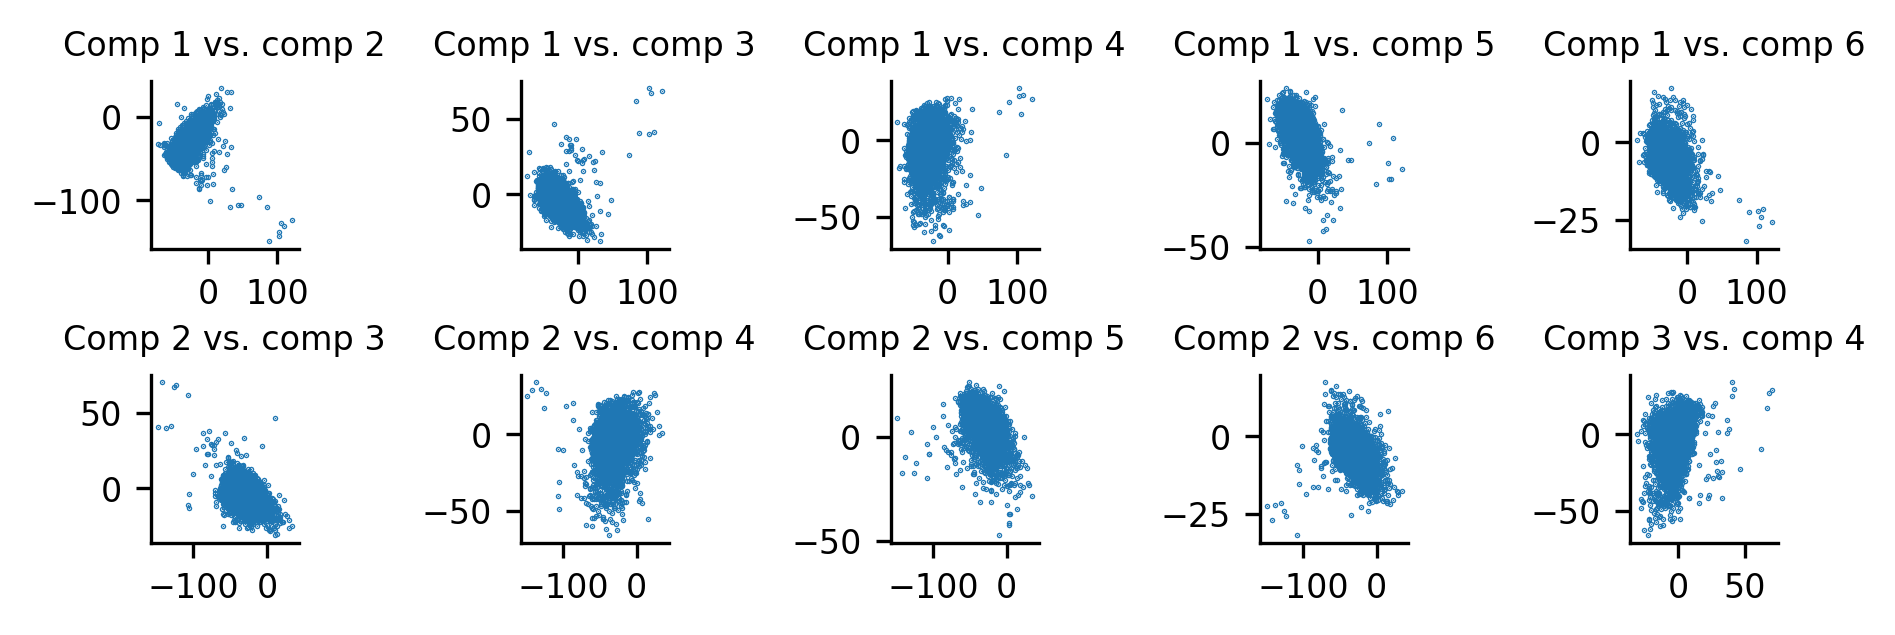

In [ ]:
fig, ax = plt.subplots(2,5, figsize = (7,2))

comp_pairs = (list(combinations(np.arange(6), 2)))
i = 0
for row in range(2):
    for col in range(5):

        ax[row, col].spines['top'].set_visible(False)
        ax[row, col].spines['right'].set_visible(False)
        ax[row, col].tick_params(labelsize = fontsize)

        c0, c1 = comp_pairs[i]
        ax[row, col].scatter(res_transformed_pca[:,-1,c0], res_transformed_pca[:,-1,c1], s = 0.1) # last epoch
        ax[row, col].set_title(f"Comp {c0+1} vs. comp {c1+1}", fontsize = fontsize)
        i+=1

fig.subplots_adjust(hspace = 0.75, wspace = 1.5)
figname = '2d_model_pcaprojection_first_round.svg'
savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
plt.savefig(savepath, transparent = False, facecolor = 'white',
           bbox_inches = 'tight', dpi = 300)

In [ ]:
lgn_params = [
    'Frequency-time slope',
    'Onset time',
    'Tuning center',
    'Tuning midline',
    'Tuning gain',
    'Tuning bandwidth',
    'Response duration'
]

v1_params = [
    'Inhibition delay',
    'Inhibition weight'
]

lgn_units = [
    'dLGN_1 into V1_1',
    'dLGN_2 into V1_1',
    'dLGN_3 into V1_1',
    'dLGN_1 into V1_2',
    'dLGN_2 into V1_2',
    'dLGN_3 into V1_2',
]

v1_units = [
    'V1_1',
    'V1_2'
]

full_lgn_params = []
for unit in lgn_units:
    for param in lgn_params:
        full_lgn_params.append(f"{param} ({unit})")

full_v1_params = []
for unit in v1_units:
    for param in v1_params:
        full_v1_params.append(f"{param} ({unit})")
        
param_names = full_lgn_params+full_v1_params

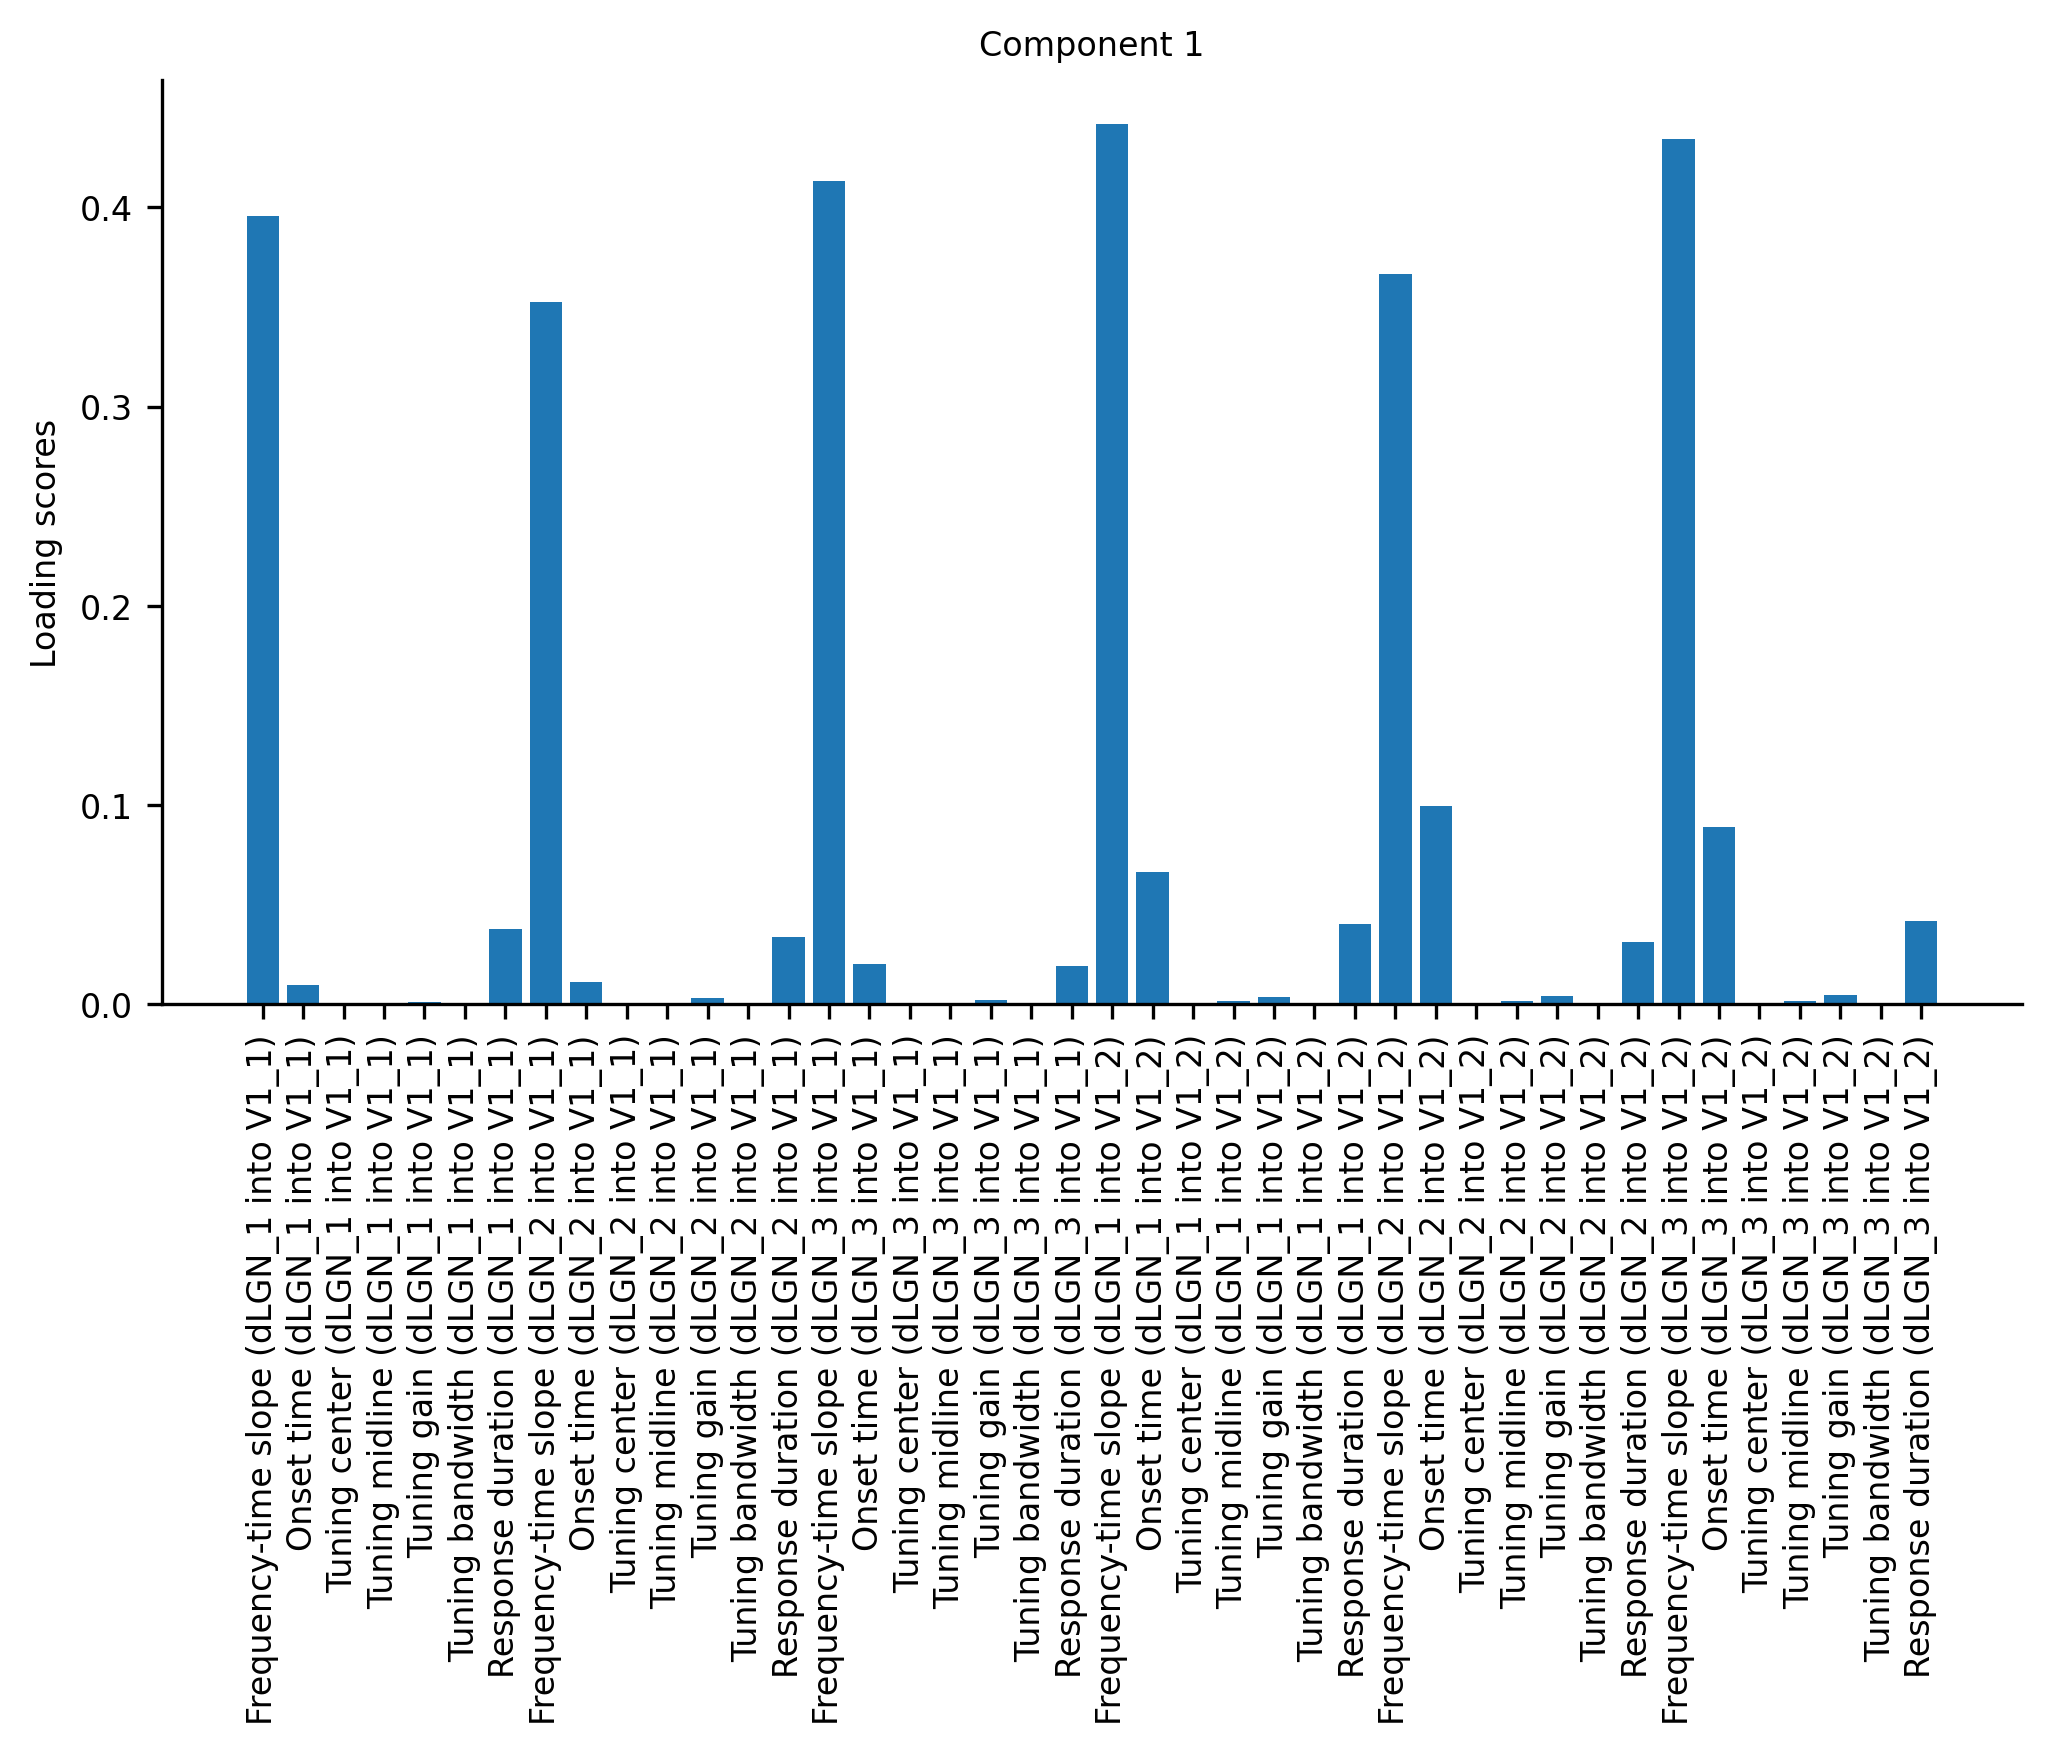

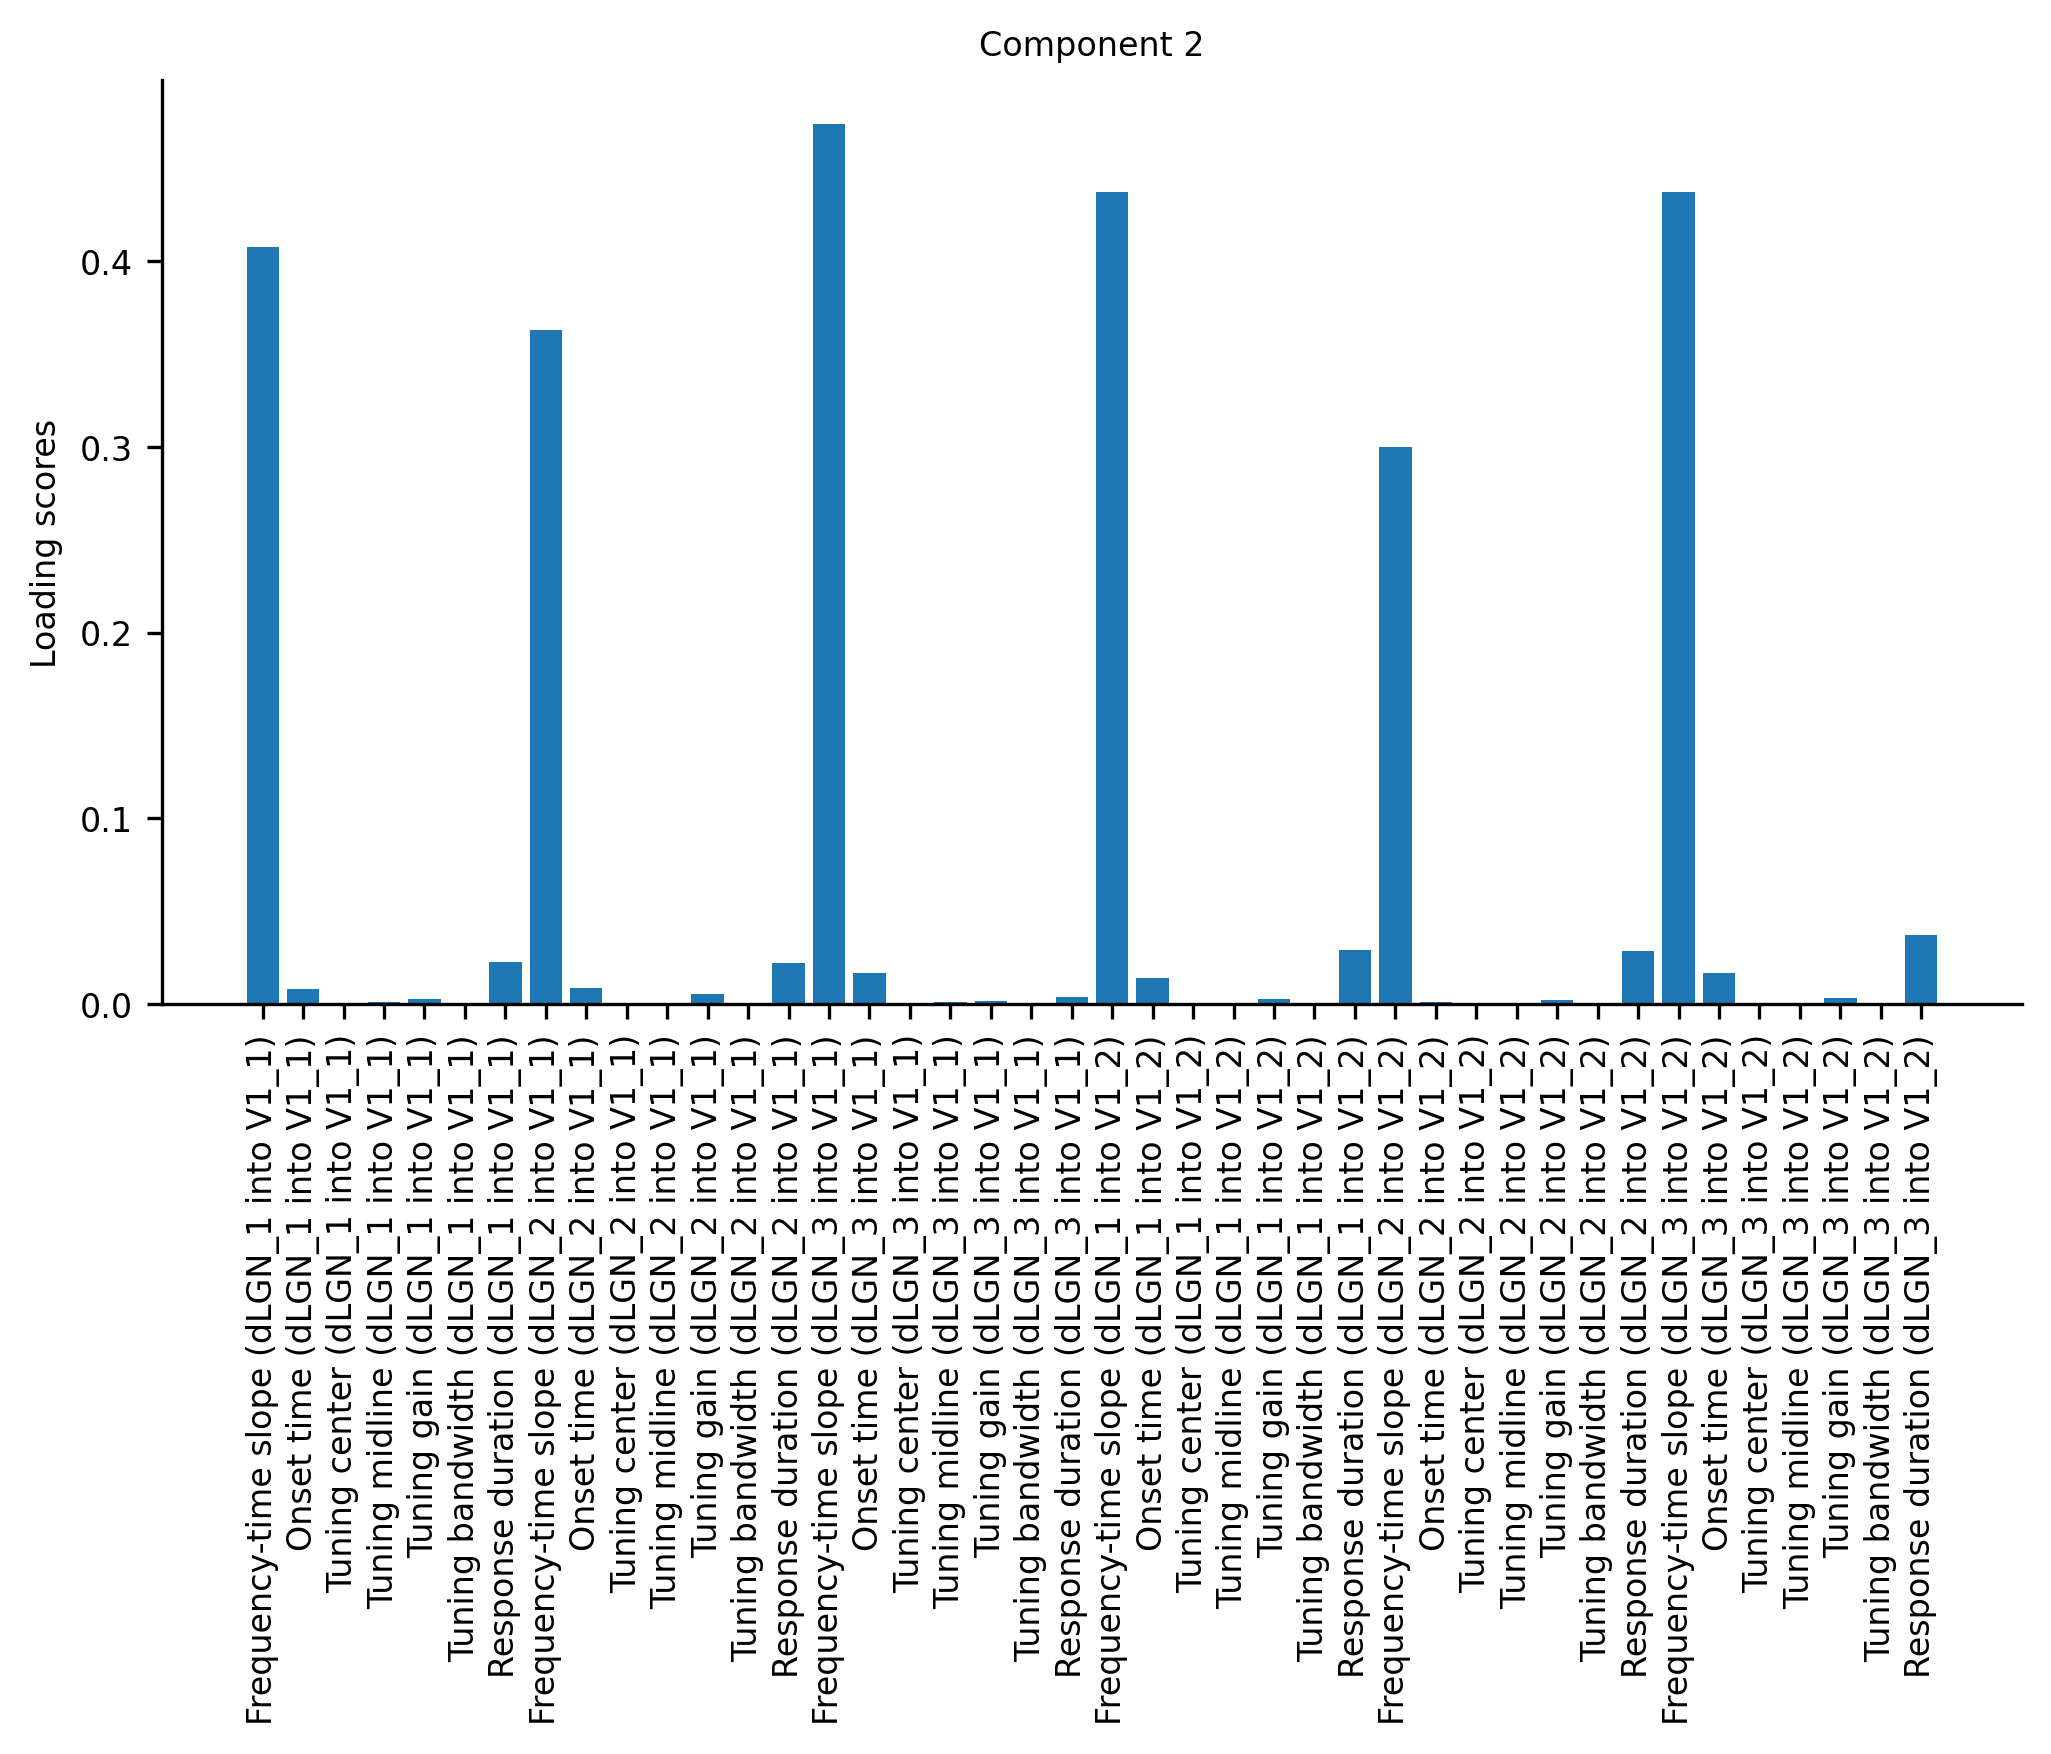

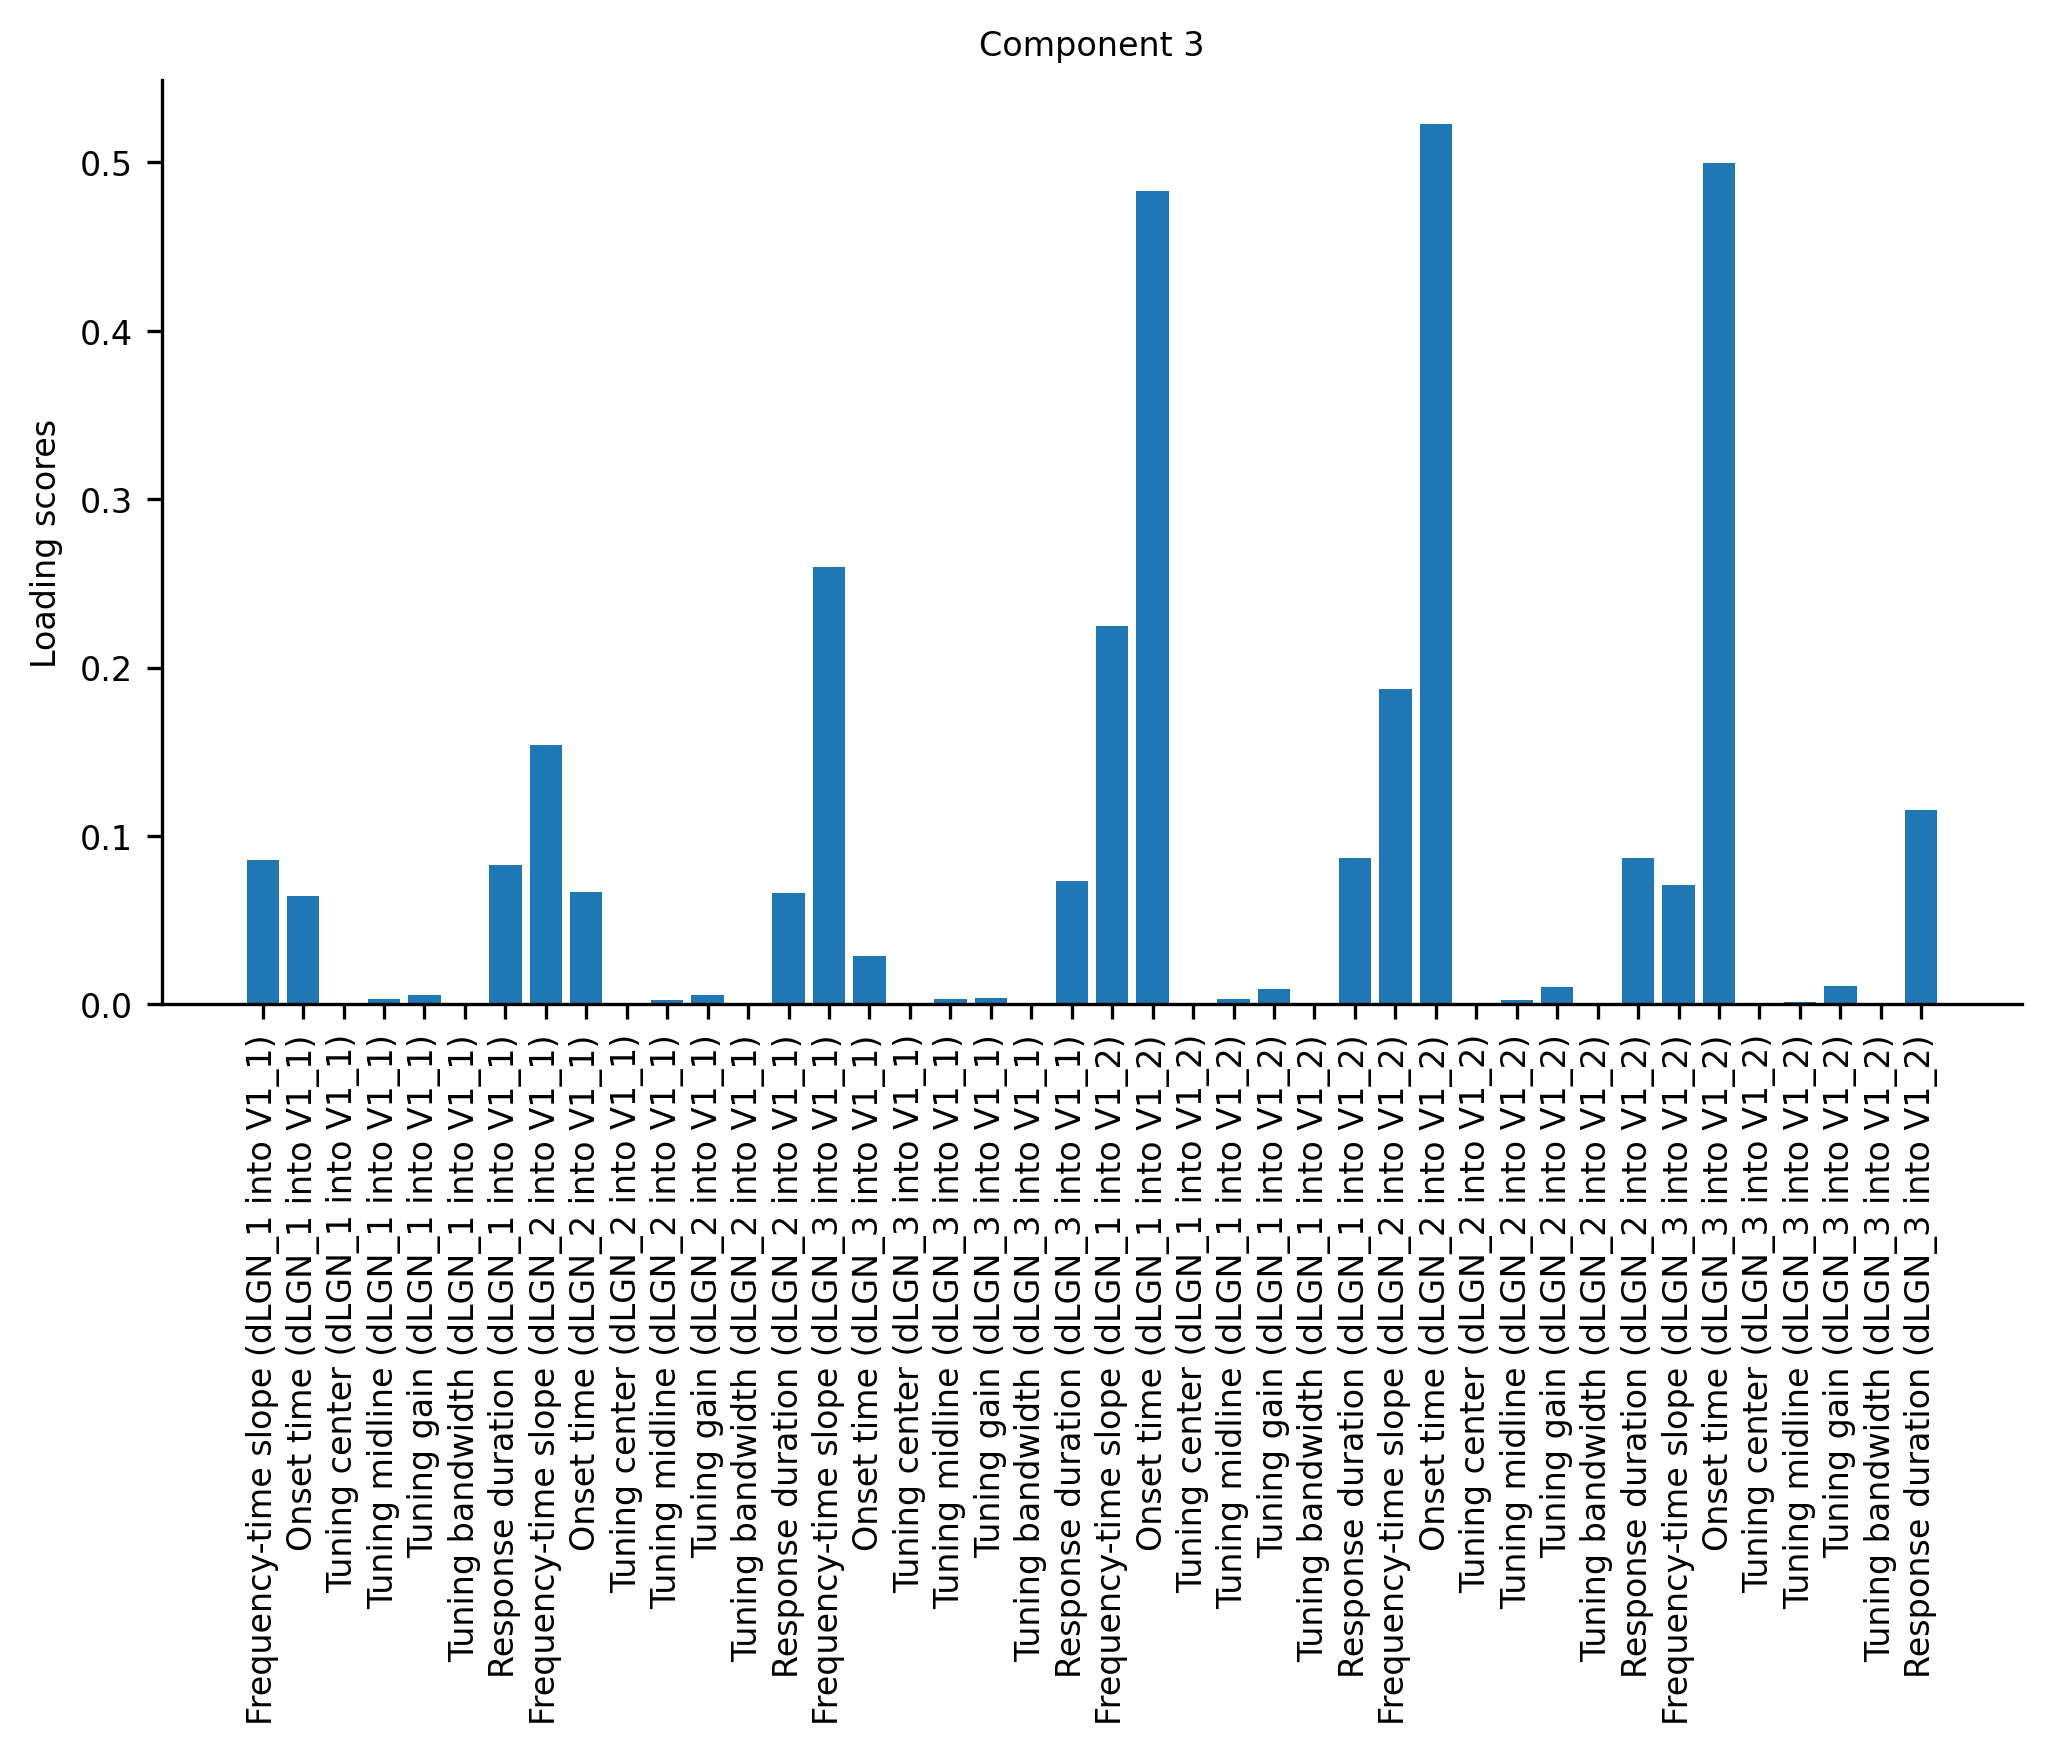

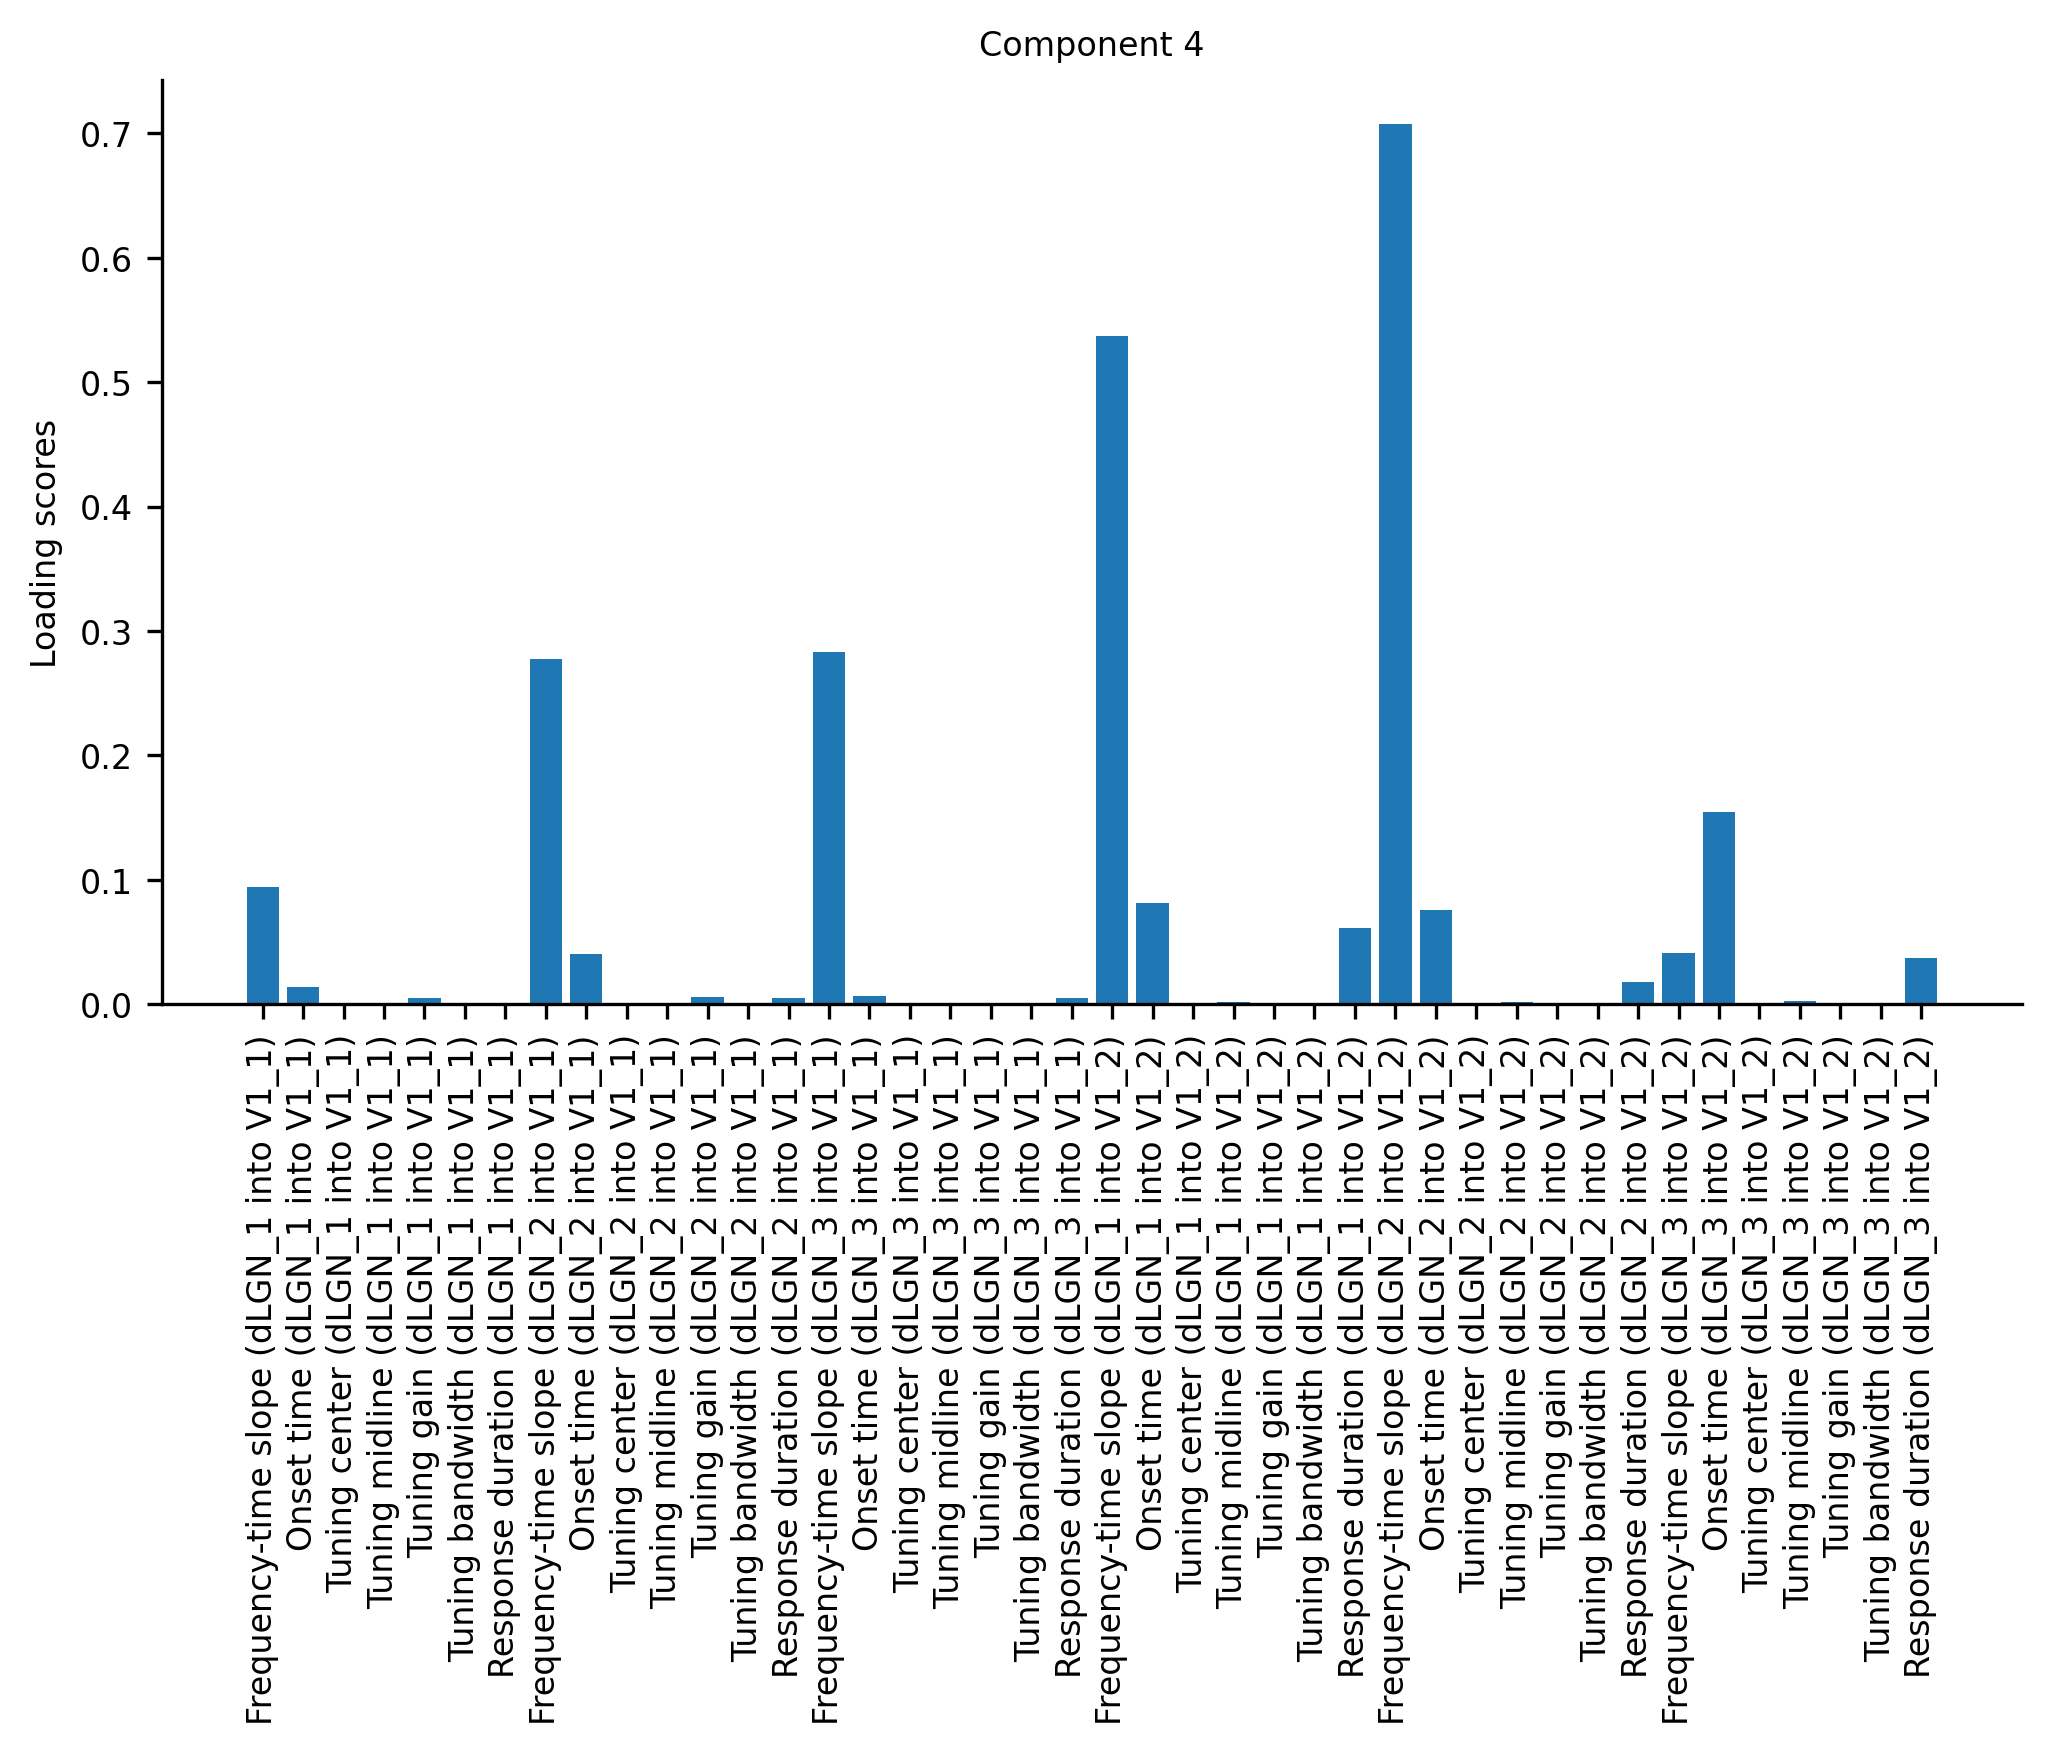

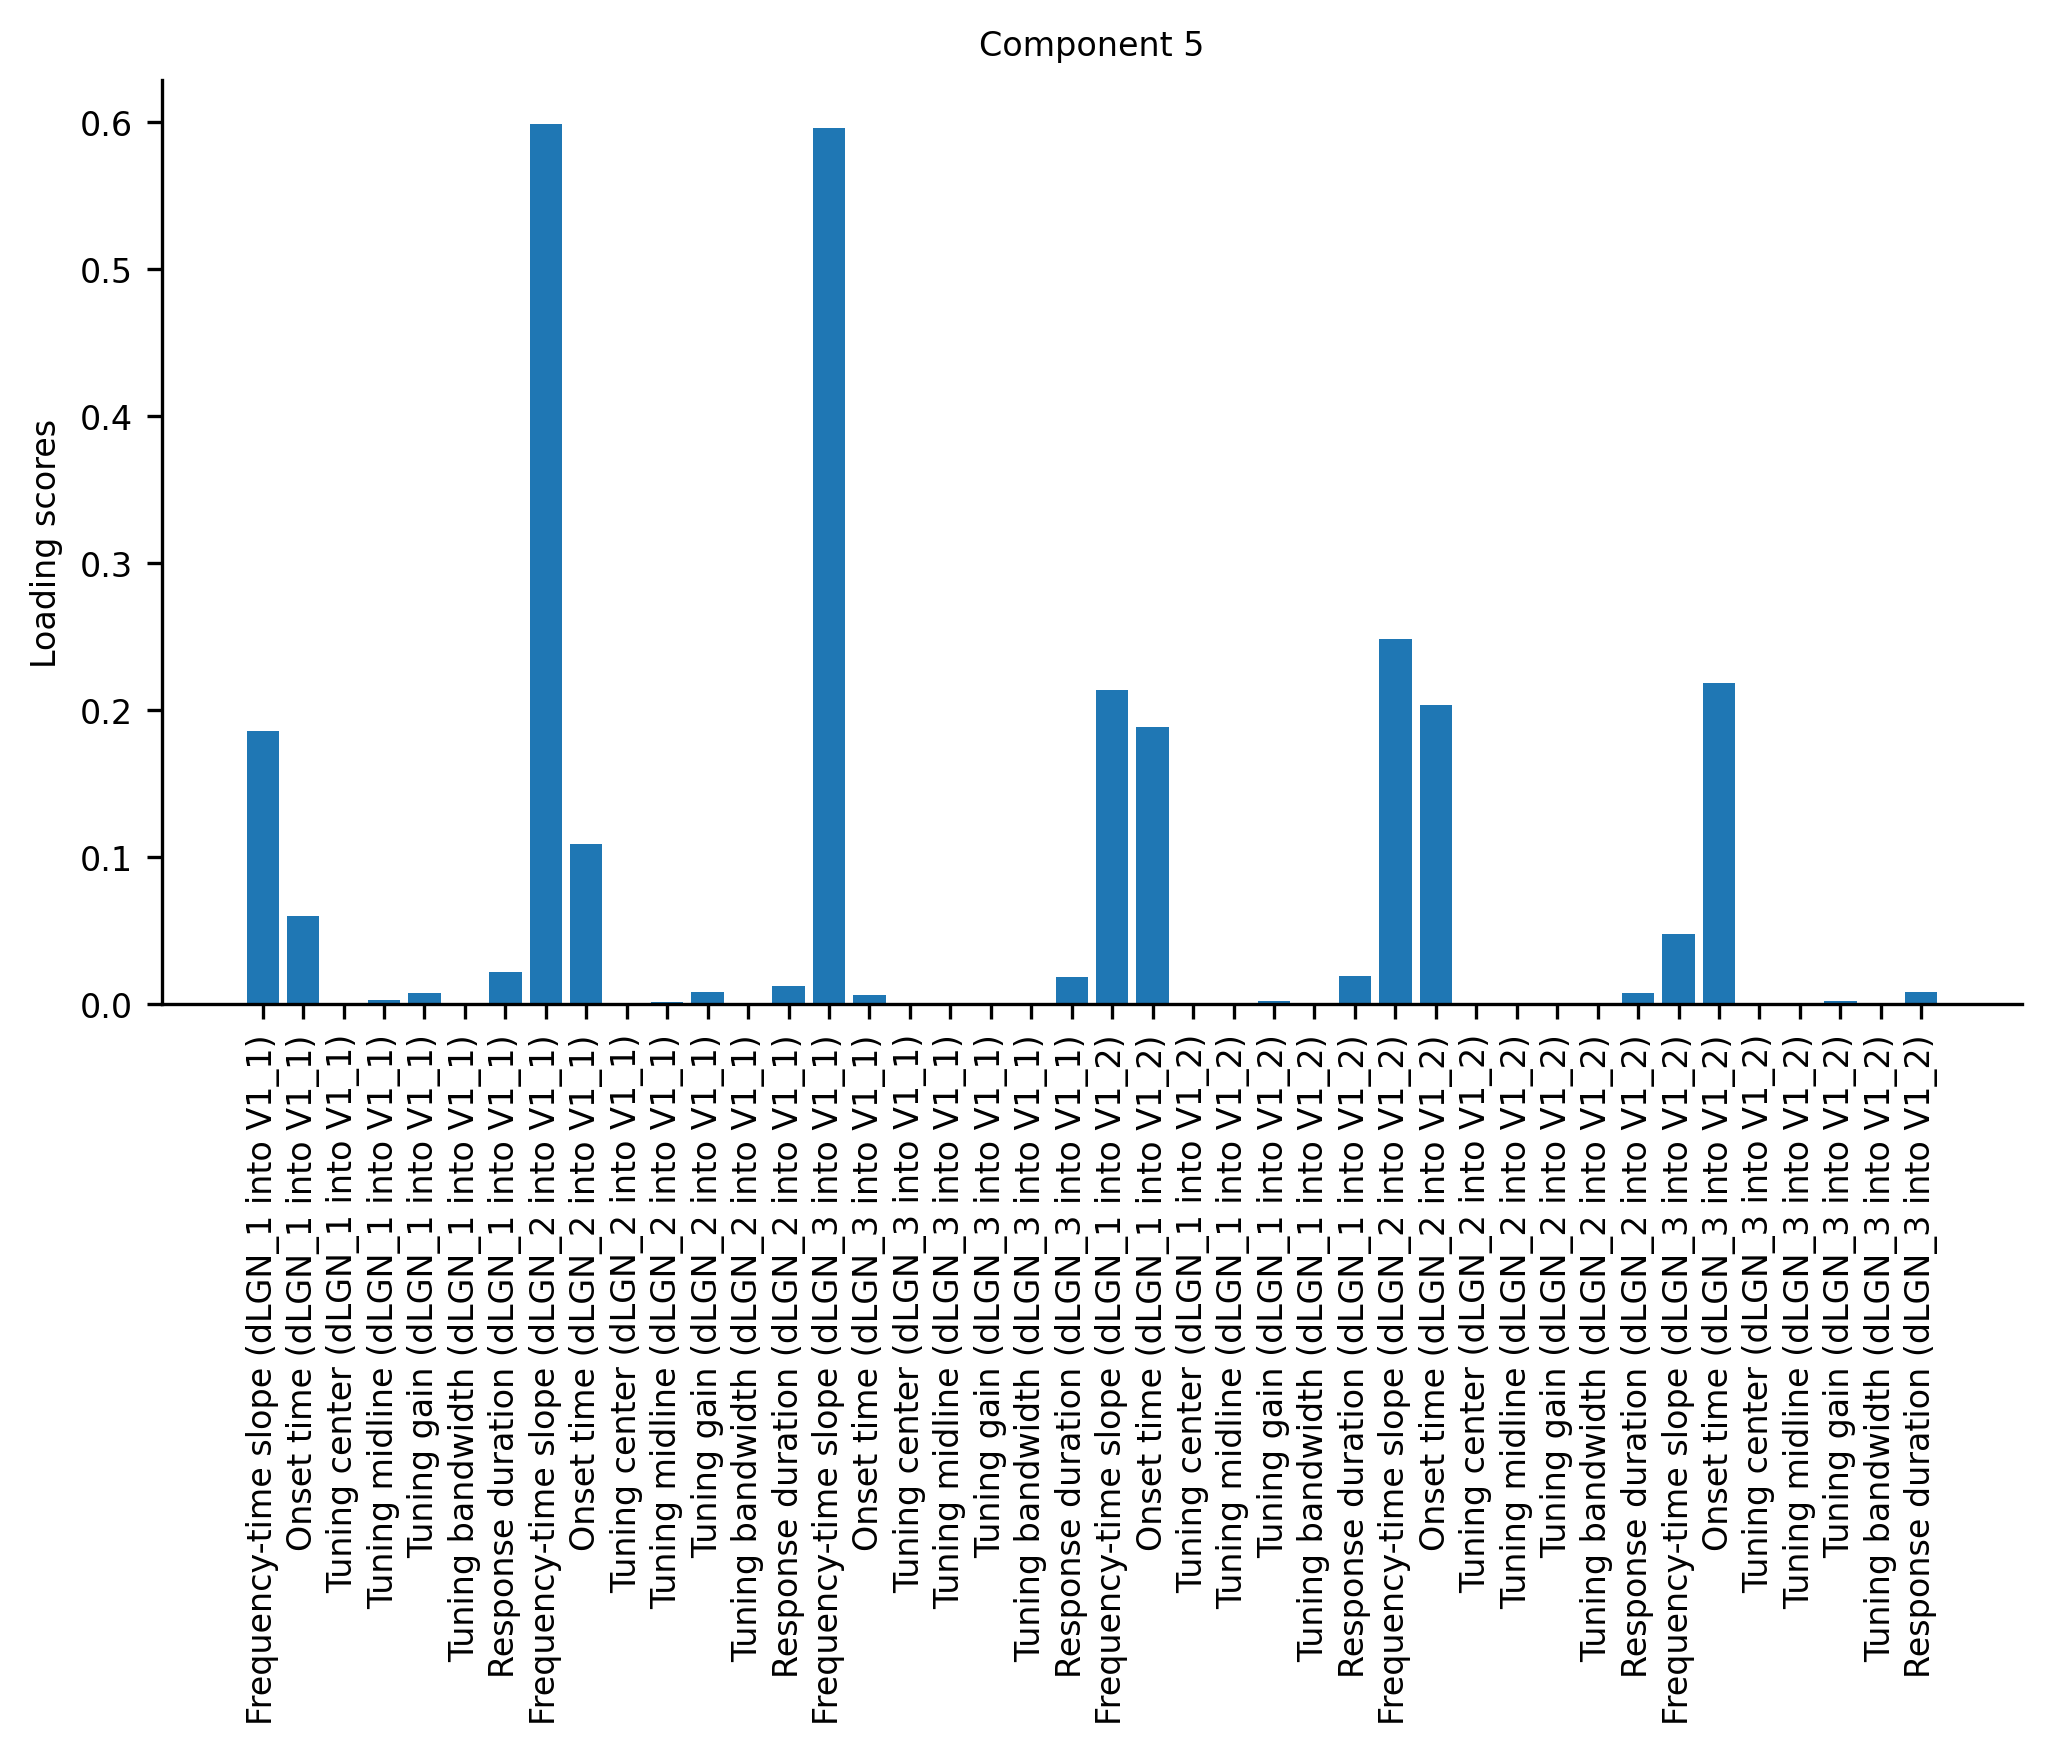

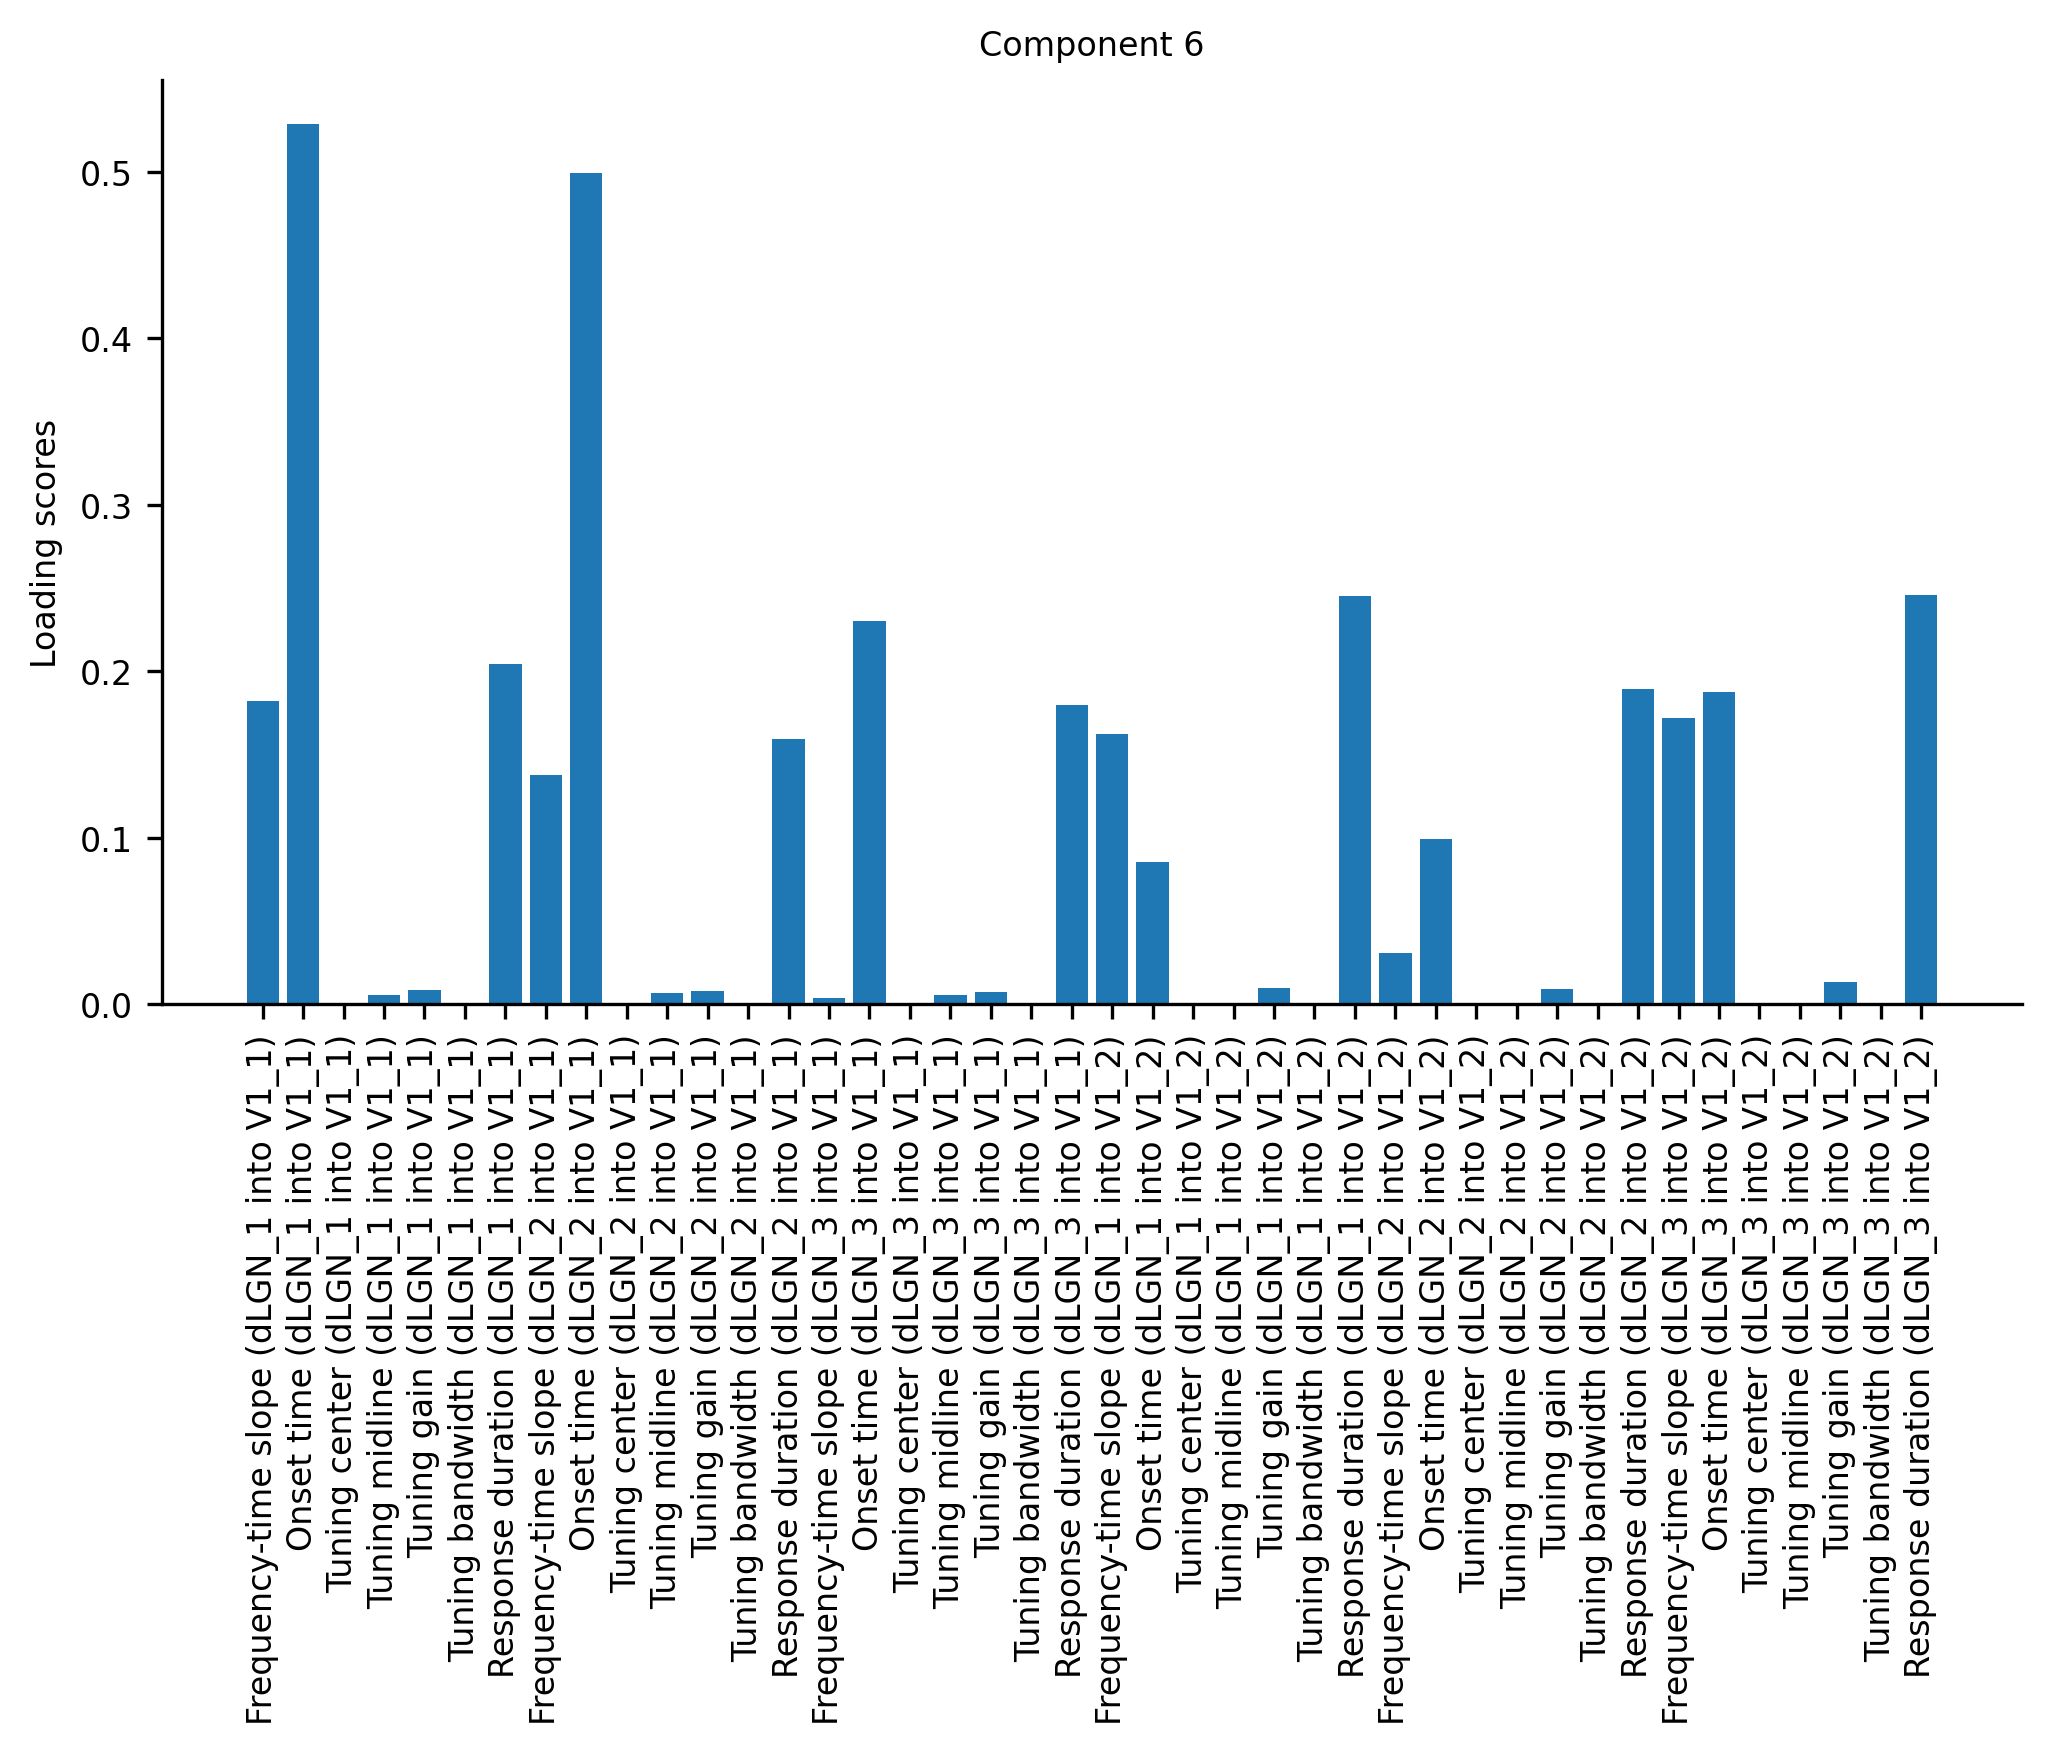

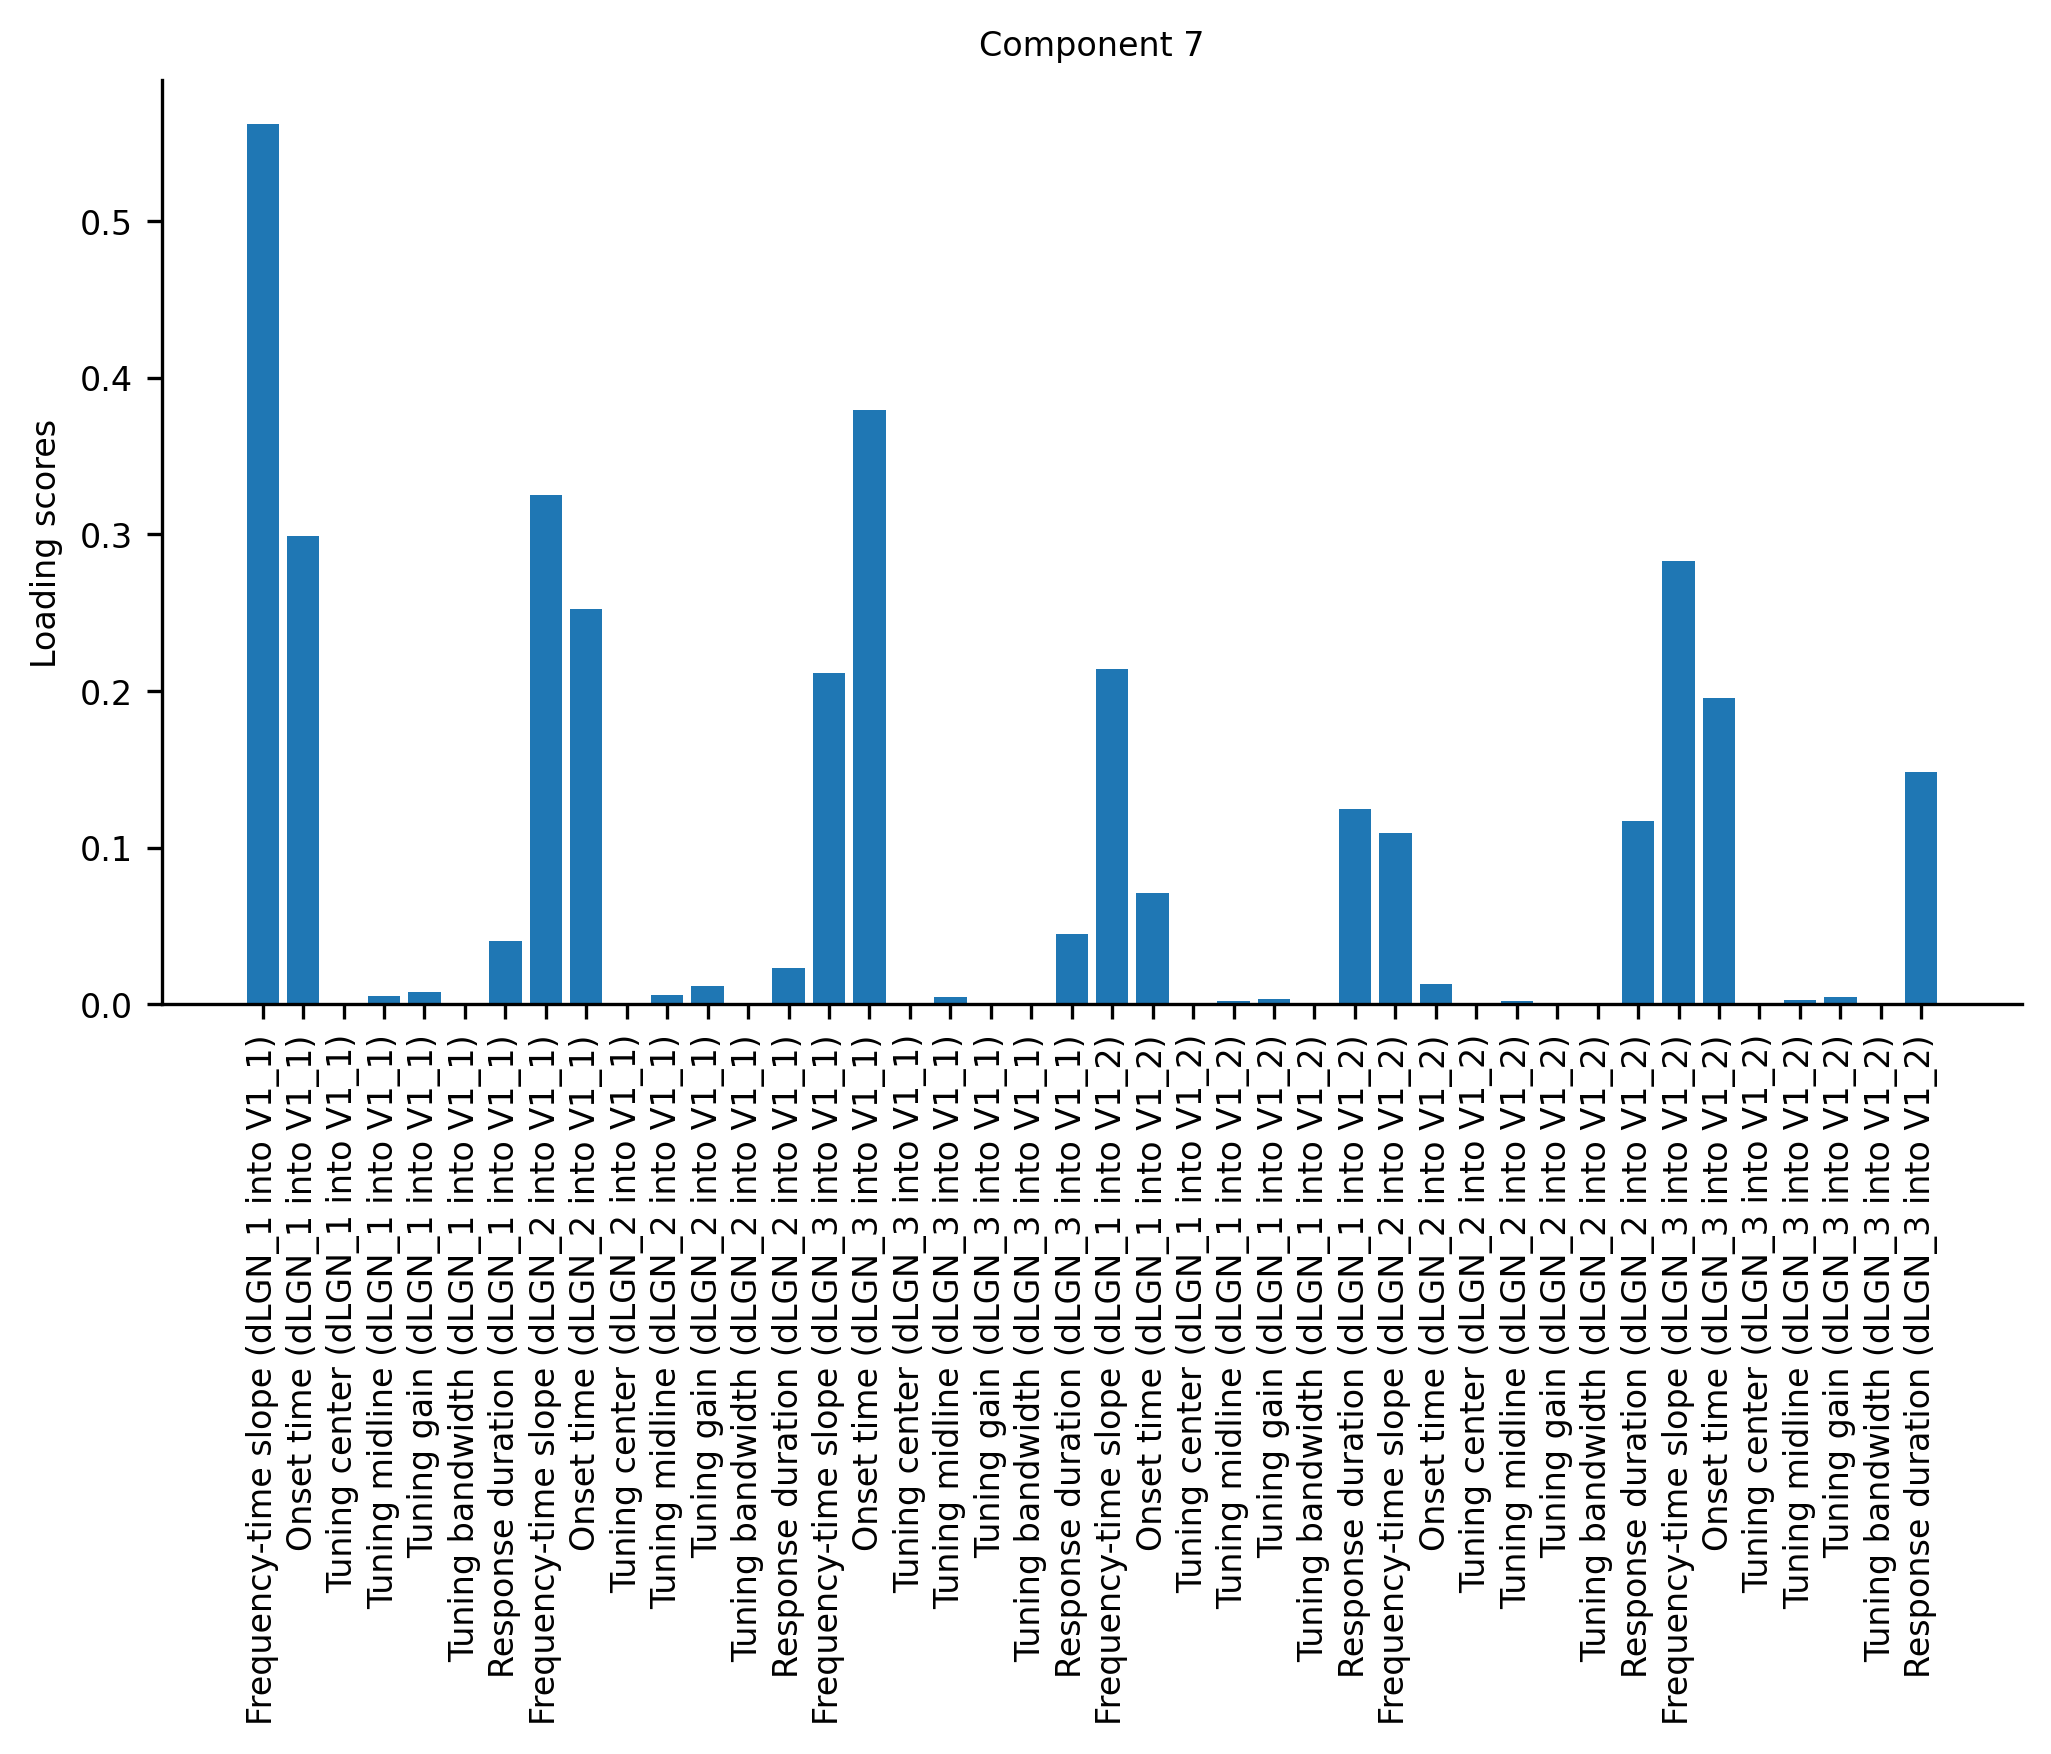

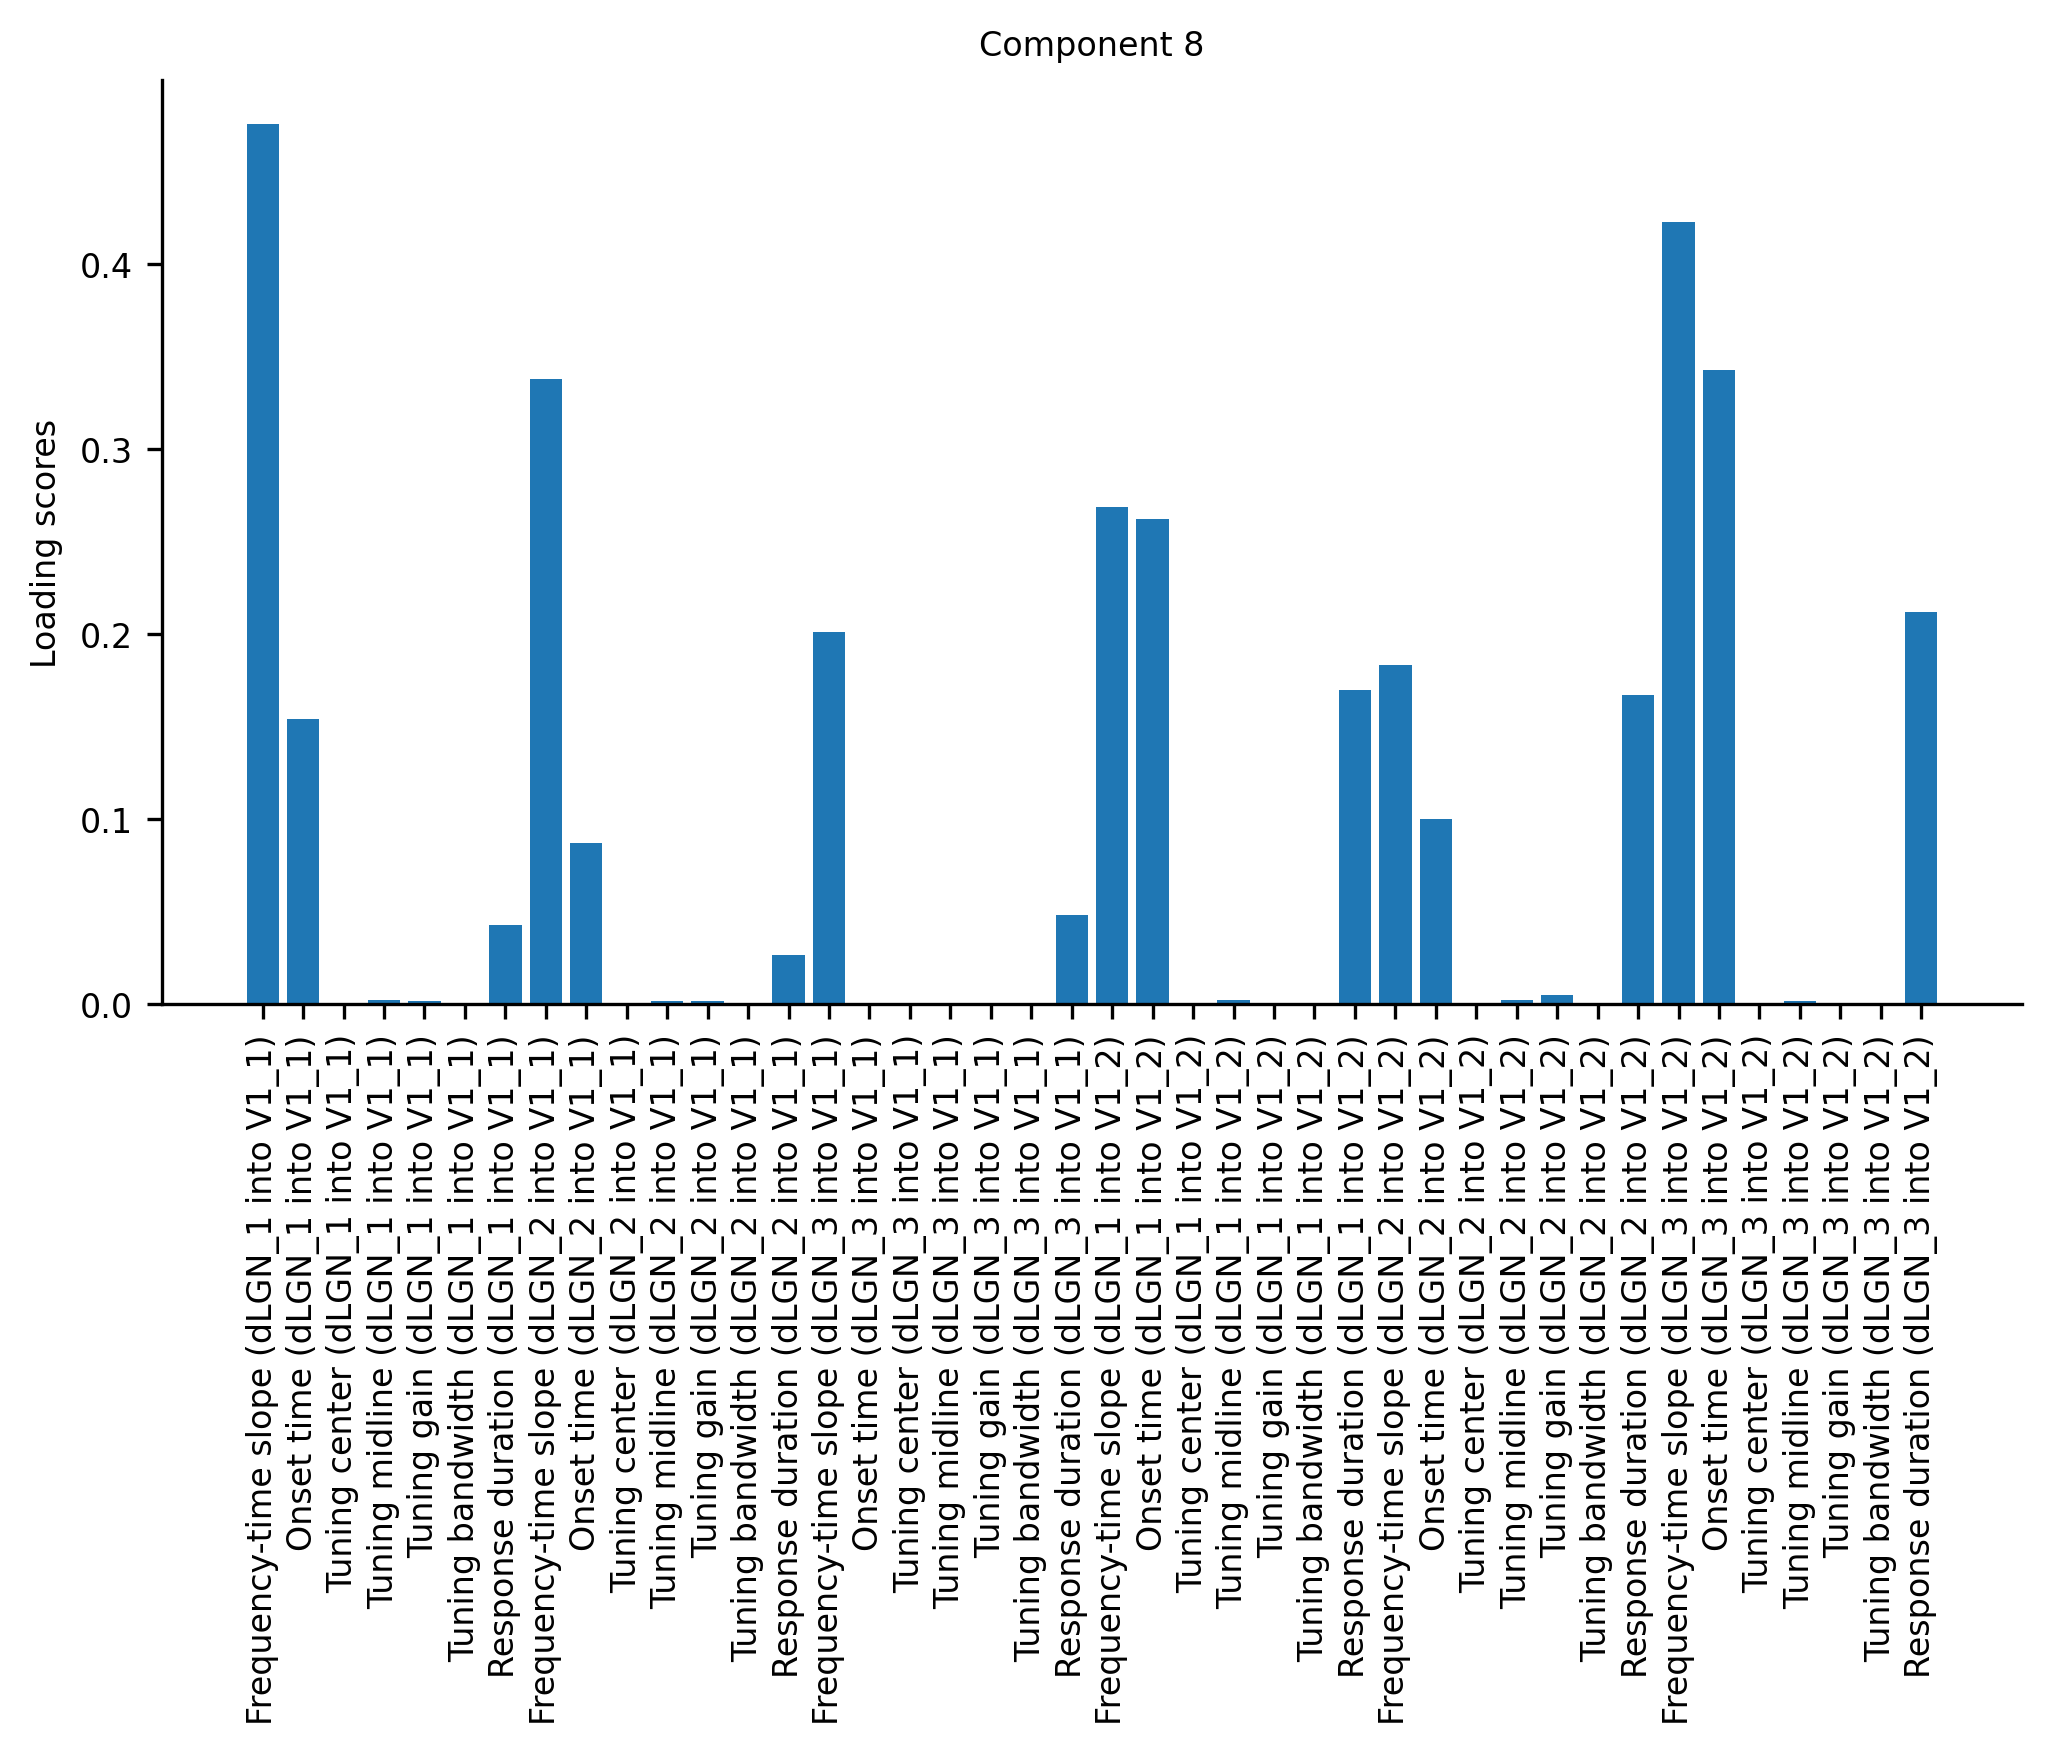

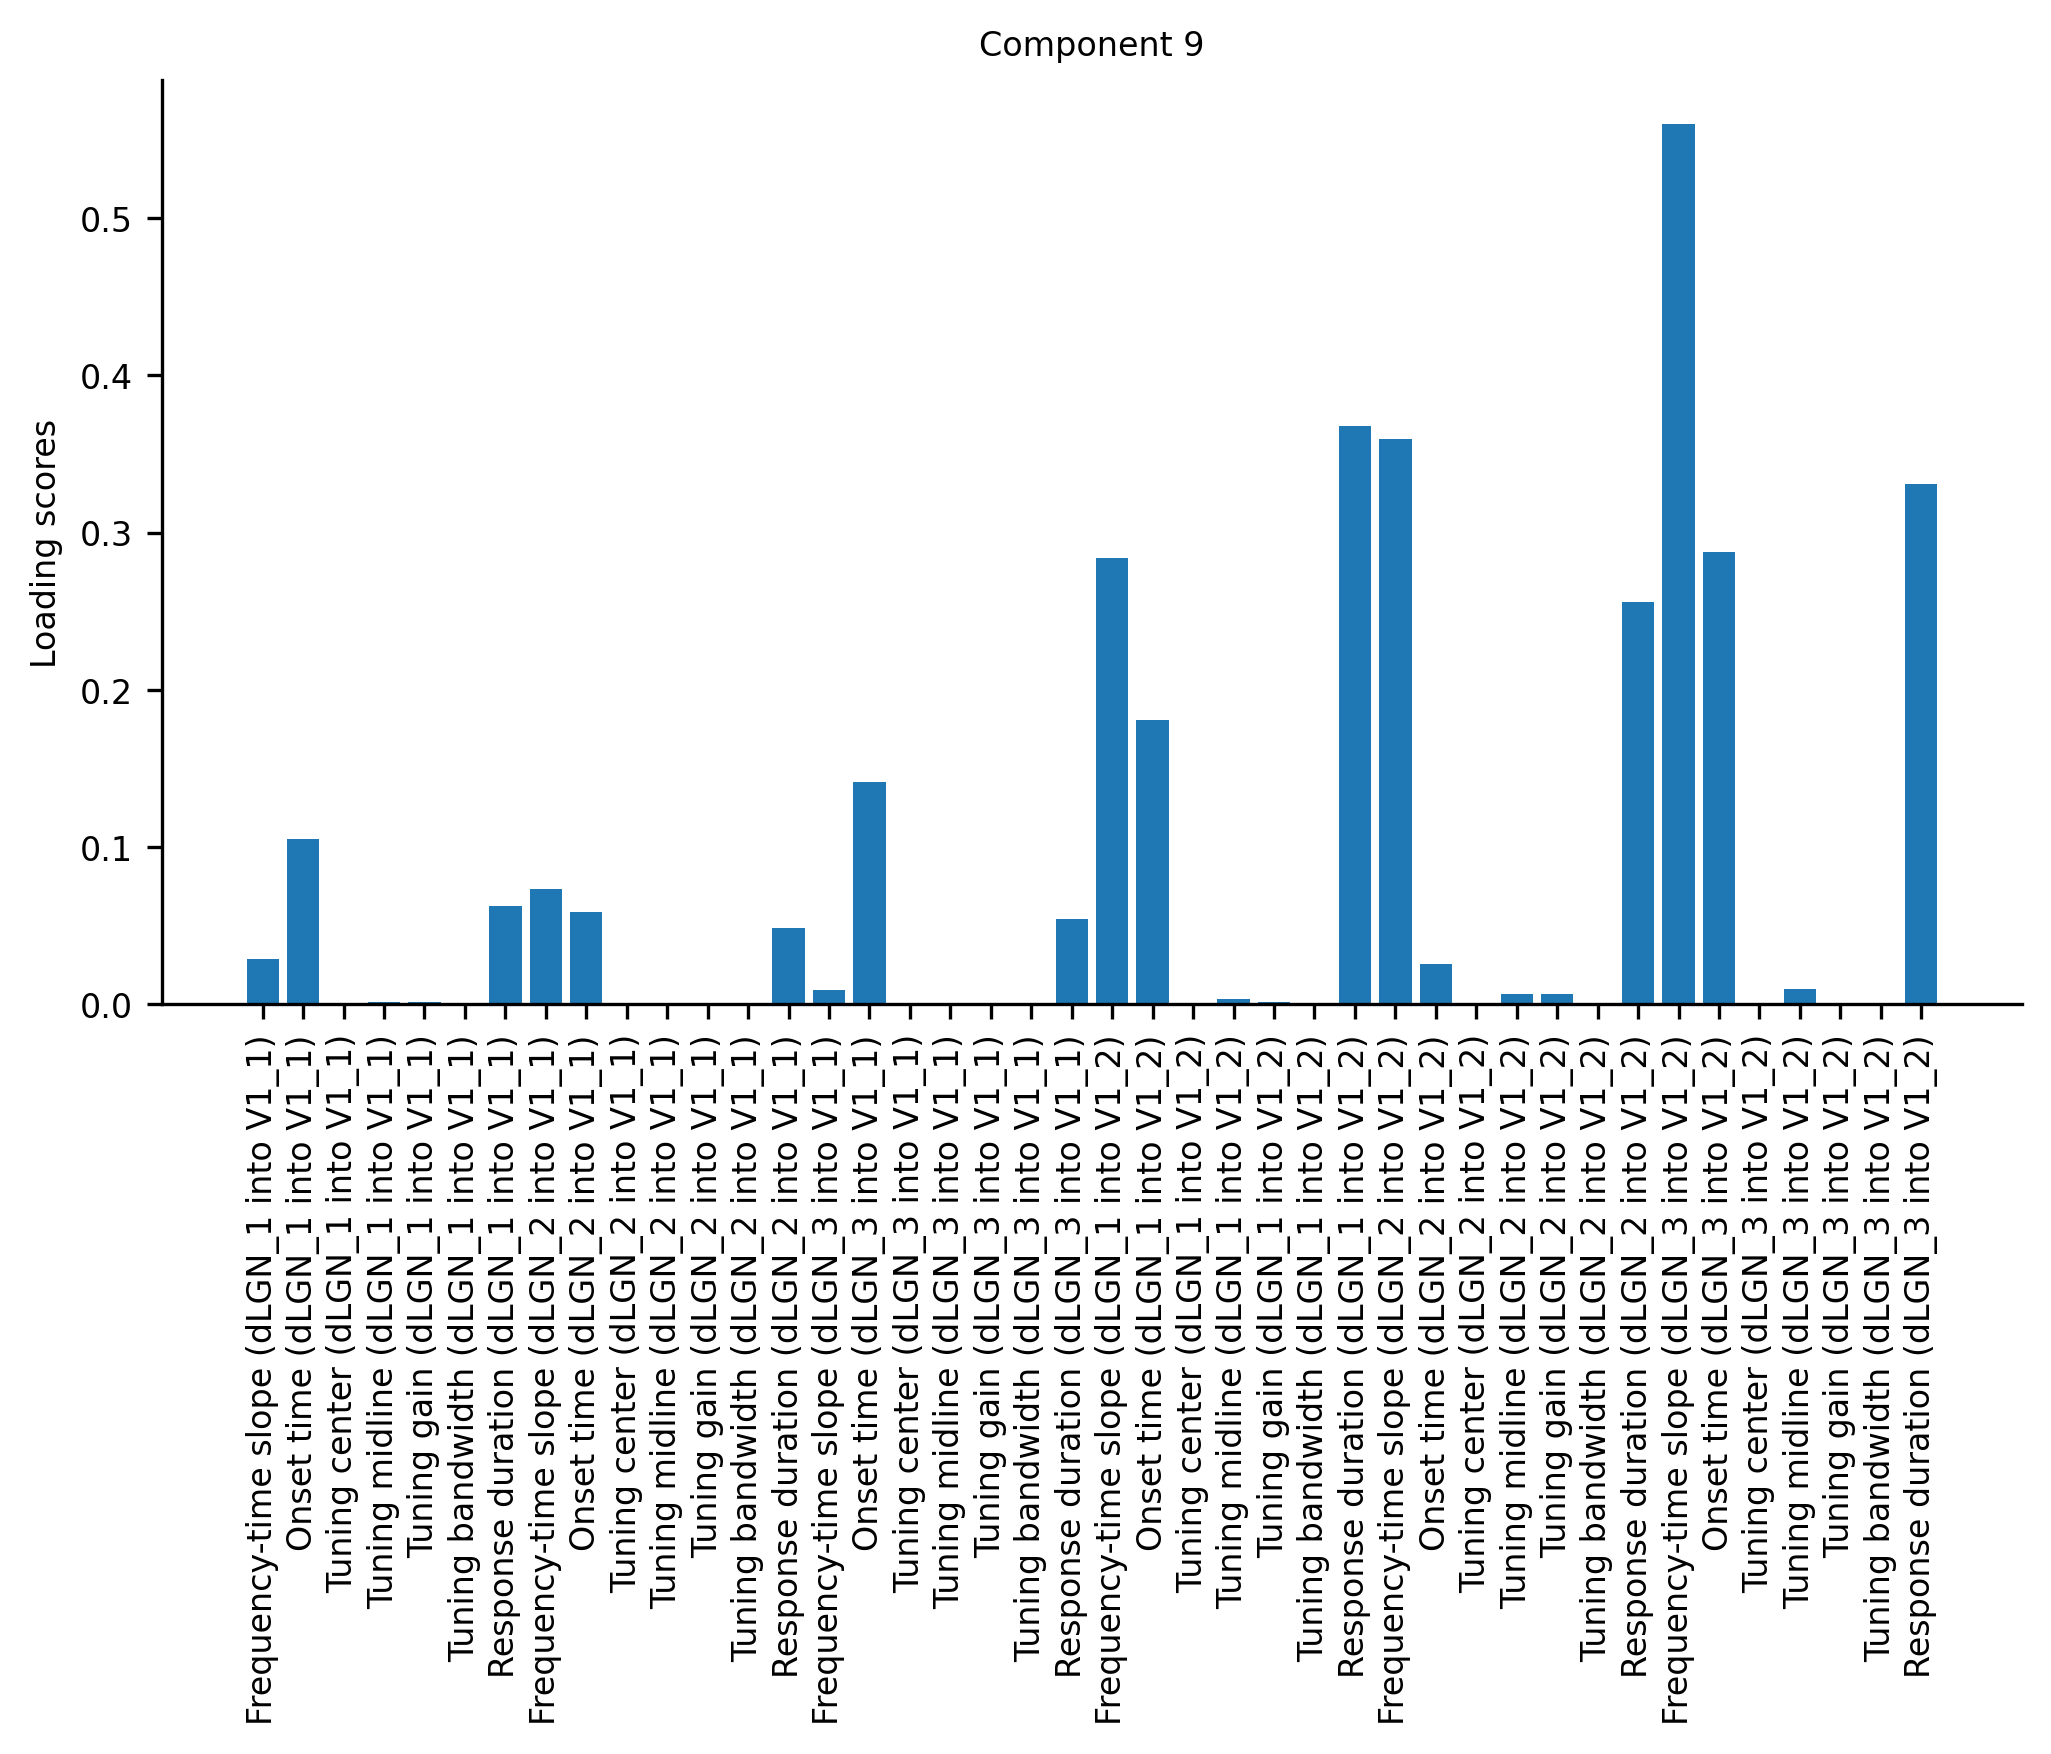

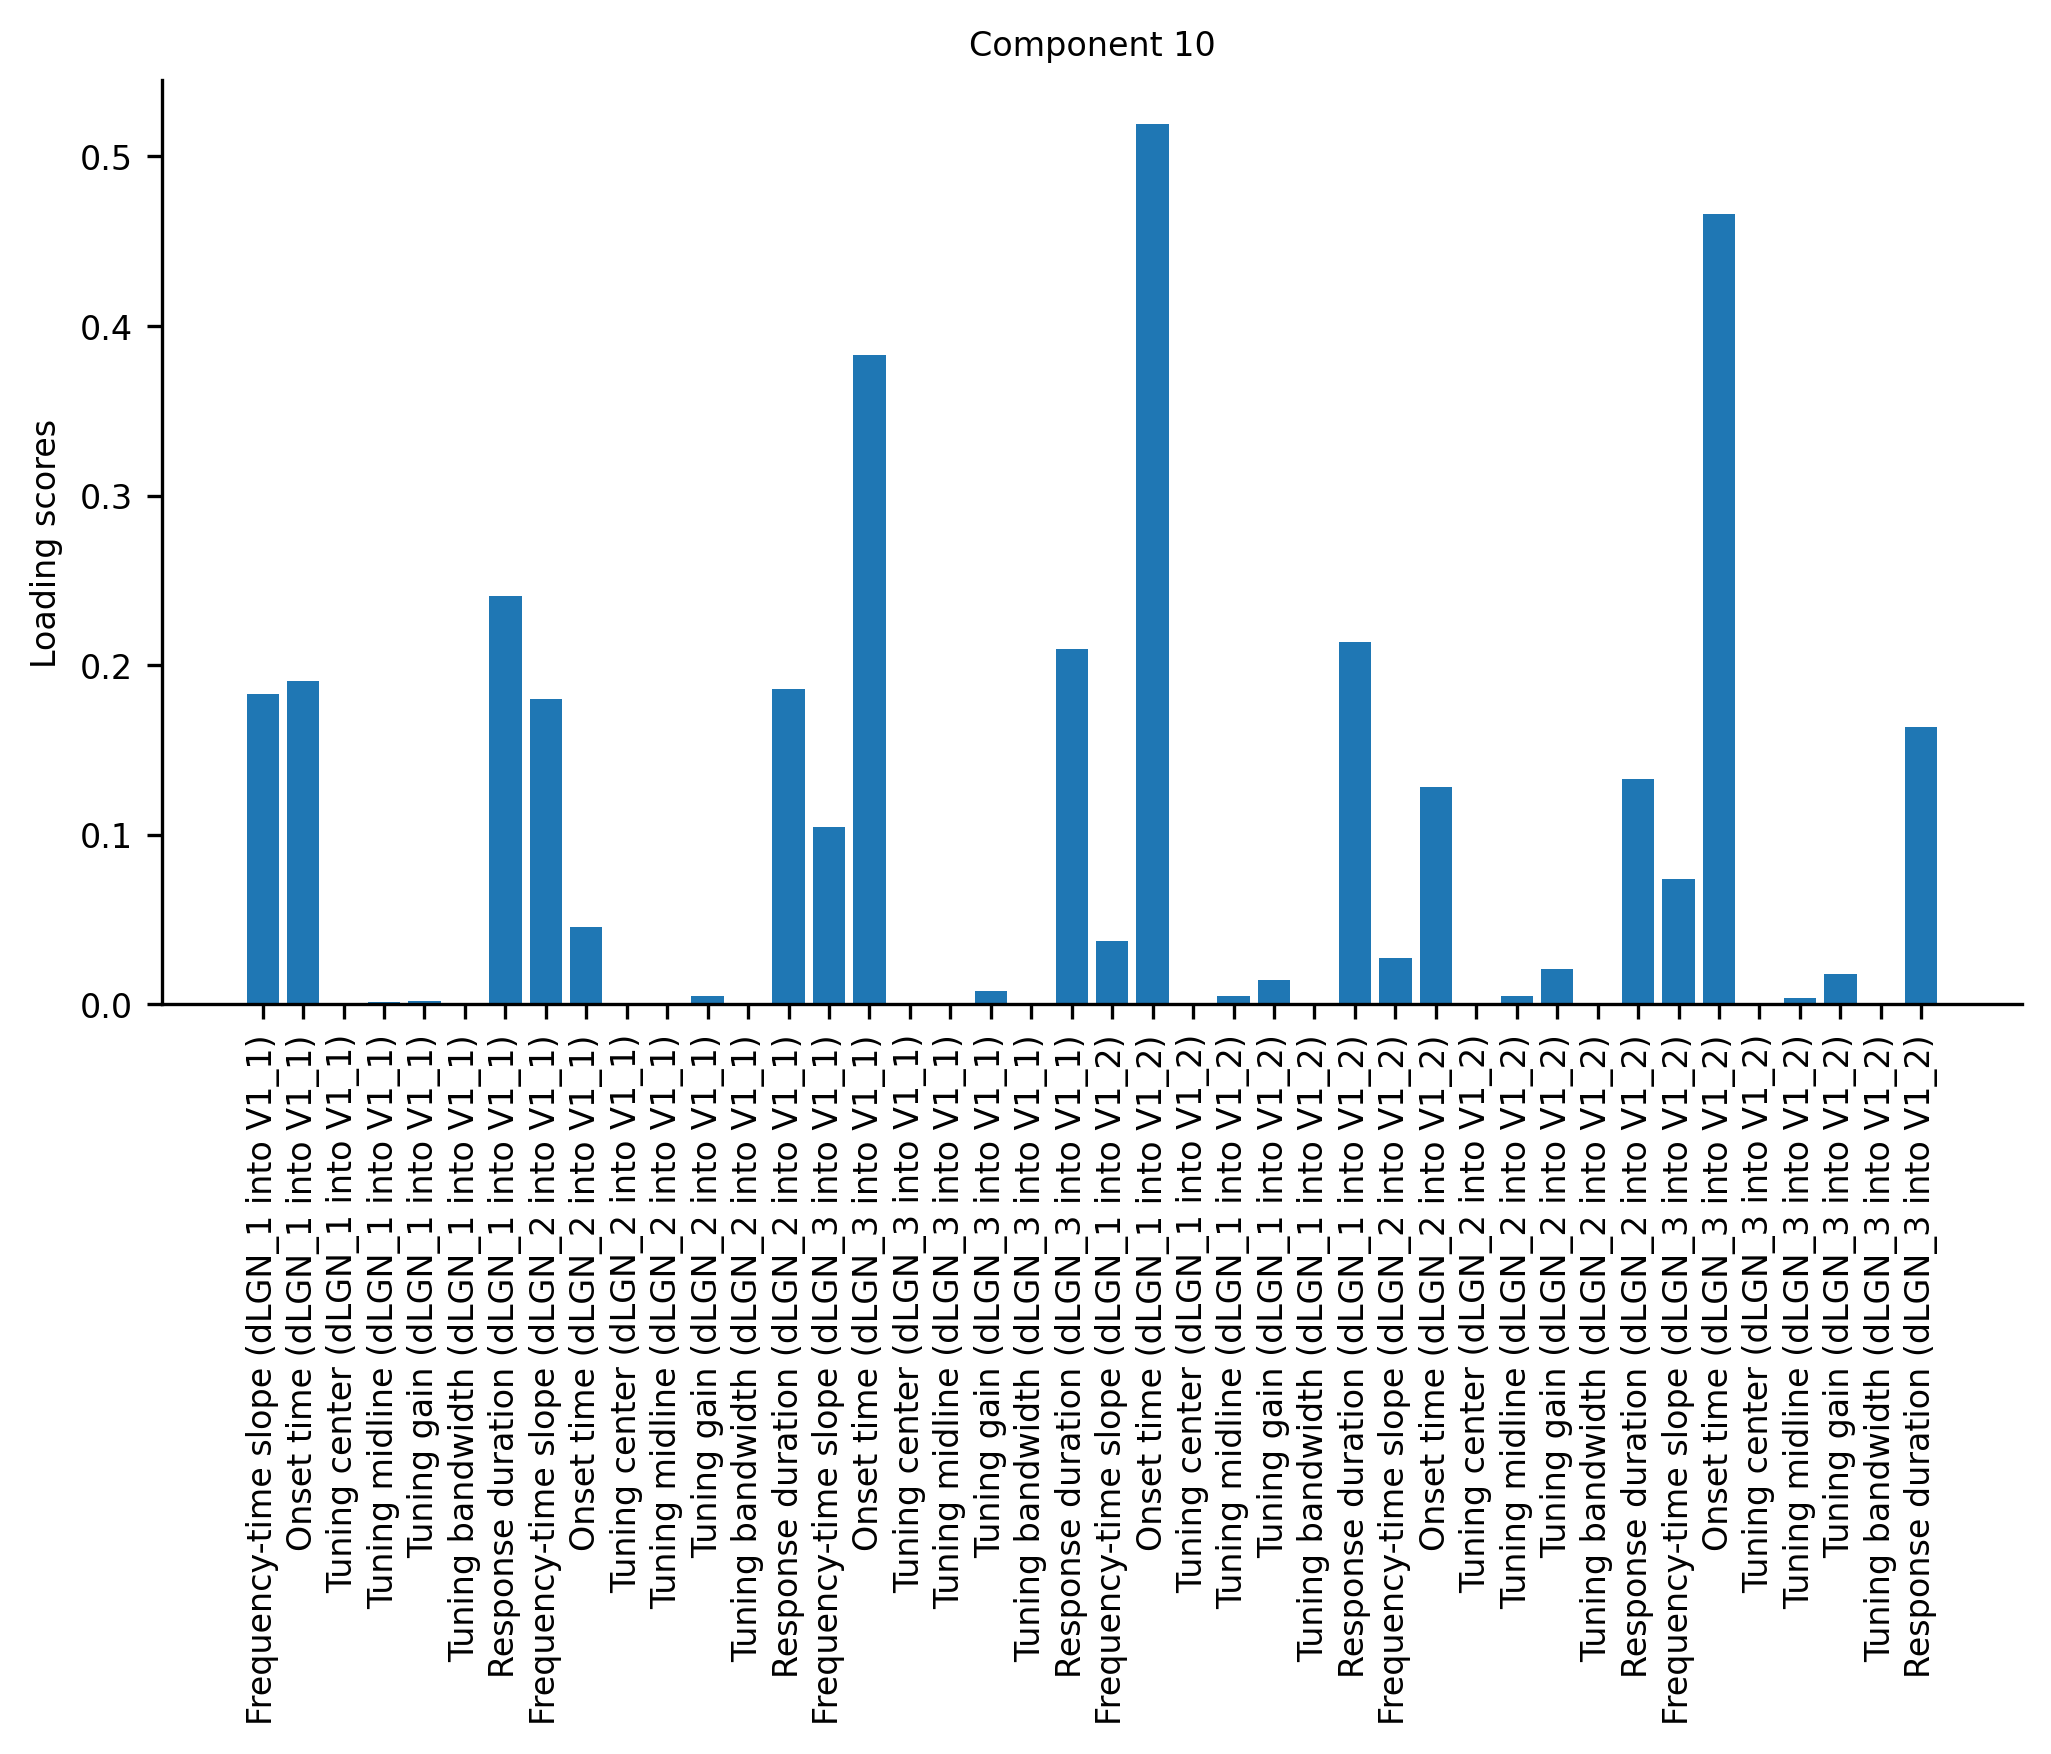

In [ ]:
for i in range(10):
    fig, ax = plt.subplots(figsize = (8, 4))
    ax.tick_params(labelsize = fontsize)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.bar(np.arange(len(full_lgn_params)), np.abs(pca.components_[i]))
    ax.set_xticks(np.arange(len(full_lgn_params)))
    ax.set_xticklabels(param_names[:len(full_lgn_params)], rotation = 90)
    ax.set_ylabel("Loading scores", fontsize = fontsize)
    ax.set_title(f"Component {i+1}", fontsize = fontsize)

    figname = f'2d_model_pca_loadings_pc{i+1}_first_round.svg'
    savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
    plt.savefig(savepath, transparent = False, facecolor = 'white',
            bbox_inches = 'tight', dpi = 300)